# Hier-COS Output Analysis

This notebook analyzes training/test artifacts in `/scratch/g.saggini1/outputs/` and compares Hier-COS variants across datasets.

Default setup:
- baseline run per dataset: `hiercos_<dataset>` (`model.loss=kl_reg`)
- CE ablation variants: `hiercos_<dataset>_ce_equal`, `_ce_kl_leaf`, `_ce_kl_coarse`
- abs-node CE + lex variants: `hiercos_<dataset>_ce_abs_node_equal`, `_ce_abs_node_kl_leaf`, `_ce_abs_node_kl_coarse`
- per_level_kl_reg + lex variants: `hiercos_<dataset>_per_level_kl_reg_equal`, `_per_level_kl_reg_kl_leaf`, `_per_level_kl_reg_kl_coarse`

It includes:
- validation curves for `FPA`, `weighted AP`, `TICE`, and `AHD`,
- per-level validation top-down/independent accuracy curves,
- training loss comparisons (`total`, `level_ce`, `kl`, `reg`, and `loss_level_*` when available),
- optional projection/gradient diagnostics when those metrics are present in logs,
- final test comparison tables with deltas versus dataset baseline.


In [43]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HierCosAnalysis,
    HCastAnalysisConfig as HierCosAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [44]:
INCLUDE_BASELINES = True
BASELINE_COLOR = "#243ab4"
WEIGHTED_LEVEL_LOSSES = True  # True: multiply loss_level_* by fixed Hier-COS CE level weights when available

BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hiercos_cifar100_per_level_kl_reg_kl_leaf_nolex', 'label': 'Hier-COS per_level_kl_reg kl_leaf nolex'},
    'cub-200-2011': {'run_dir': 'hiercos_cub200_per_level_kl_reg_kl_leaf_nolex', 'label': 'Hier-COS per_level_kl_reg kl_leaf nolex'},
    'fgvc-aircraft': {'run_dir': 'hiercos_aircraft_per_level_kl_reg_kl_leaf_nolex', 'label': 'Hier-COS per_level_kl_reg kl_leaf nolex'},
}

MANUAL_RUNS = [
    # # CIFAR100 (Abs-Node CE + Lex)
    # {'run_dir': 'hiercos_cifar100_ce_equal', 'label': 'Hier-COS CE equal'},
    # {'run_dir': 'hiercos_cifar100_ce_kl_leaf', 'label': 'Hier-COS CE kl_leaf'},
    # {'run_dir': 'hiercos_cifar100_ce_kl_coarse', 'label': 'Hier-COS CE kl_coarse'},

    # # CUB200 (Abs-Node CE + Lex)
    # {'run_dir': 'hiercos_cub200_ce_equal', 'label': 'Hier-COS CE equal'},
    # {'run_dir': 'hiercos_cub200_ce_kl_leaf', 'label': 'Hier-COS CE kl_leaf'},
    # {'run_dir': 'hiercos_cub200_ce_kl_coarse', 'label': 'Hier-COS CE kl_coarse'},

    # # Aircraft (Abs-Node CE + Lex)
    # {'run_dir': 'hiercos_aircraft_ce_equal', 'label': 'Hier-COS CE equal'},
    # {'run_dir': 'hiercos_aircraft_ce_kl_leaf', 'label': 'Hier-COS CE kl_leaf'},
    # {'run_dir': 'hiercos_aircraft_ce_kl_coarse', 'label': 'Hier-COS CE kl_coarse'},


    # CIFAR100 (per_level_kl_reg + Lex)
    # {'run_dir': 'hiercos_cifar100_per_level_kl_reg_equal', 'label': 'Hier-COS per_level_kl_reg equal'},
    # #{'run_dir': 'hiercos_cifar100_per_level_kl_reg_kl_leaf', 'label': 'Hier-COS per_level_kl_reg kl_leaf'},
    # #{'run_dir': 'hiercos_cifar100_per_level_kl_reg_kl_coarse', 'label': 'Hier-COS per_level_kl_reg kl_coarse'},

    # # CUB200 (per_level_kl_reg + Lex)
    # #{'run_dir': 'hiercos_cub200_per_level_kl_reg_equal', 'label': 'Hier-COS per_level_kl_reg equal'},
    # {'run_dir': 'hiercos_cub200_per_level_kl_reg_kl_leaf', 'label': 'Hier-COS per_level_kl_reg kl_leaf'},
    # #{'run_dir': 'hiercos_cub200_per_level_kl_reg_kl_coarse', 'label': 'Hier-COS per_level_kl_reg kl_coarse'},

    # # Aircraft (per_level_kl_reg + Lex)
    # {'run_dir': 'hiercos_aircraft_per_level_kl_reg_equal', 'label': 'Hier-COS per_level_kl_reg equal'},
    # {'run_dir': 'hiercos_aircraft_per_level_kl_reg_kl_leaf', 'label': 'Hier-COS per_level_kl_reg kl_leaf'},
    # #{'run_dir': 'hiercos_aircraft_per_level_kl_reg_kl_coarse', 'label': 'Hier-COS per_level_kl_reg kl_coarse'},

    # CIFAR100 final only
    {'run_dir': 'hiercos_cifar100_per_level_kl_reg_equal_final_only', 'label': 'Hier-COS per_level_kl_reg equal final only'},
    # CUB200 final only, bn_linear
    {'run_dir': 'hiercos_cub200_per_level_kl_reg_kl_leaf_final_only', 'label': 'Hier-COS per_level_kl_reg kl_leaf final only'},
    {'run_dir': 'hiercos_cub200_per_level_kl_reg_kl_leaf_bnlinear', 'label': 'Hier-COS per_level_kl_reg kl_leaf bn_linear'},
    # Aircraft final only, bn_linear
    {'run_dir': 'hiercos_aircraft_per_level_kl_reg_equal_final_only', 'label': 'Hier-COS per_level_kl_reg equal final only'},
    {'run_dir': 'hiercos_aircraft_per_level_kl_reg_kl_leaf_final_only', 'label': 'Hier-COS per_level_kl_reg kl_leaf final only'},
    {'run_dir': 'hiercos_aircraft_per_level_kl_reg_equal_bnlinear', 'label': 'Hier-COS per_level_kl_reg equal bn_linear'},
    {'run_dir': 'hiercos_aircraft_per_level_kl_reg_kl_leaf_bnlinear', 'label': 'Hier-COS per_level_kl_reg kl_leaf bn_linear'},
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [45]:
config = HierCosAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HierCosAnalysis.from_config(config)
analysis.print_run_summary()


[cifar-100] Hier-COS per_level_kl_reg kl_leaf nolex: epochs=100, best_td_epoch=93, best_ind_epoch=89, baseline
[cifar-100] Hier-COS per_level_kl_reg equal final only: epochs=100, best_td_epoch=96, best_ind_epoch=96
[cub-200-2011] Hier-COS per_level_kl_reg kl_leaf nolex: epochs=100, best_td_epoch=55, best_ind_epoch=55, baseline
[cub-200-2011] Hier-COS per_level_kl_reg kl_leaf final only: epochs=100, best_td_epoch=35, best_ind_epoch=35
[cub-200-2011] Hier-COS per_level_kl_reg kl_leaf bn_linear: epochs=100, best_td_epoch=98, best_ind_epoch=83
[fgvc-aircraft] Hier-COS per_level_kl_reg kl_leaf nolex: epochs=100, best_td_epoch=59, best_ind_epoch=59, baseline
[fgvc-aircraft] Hier-COS per_level_kl_reg equal final only: epochs=100, best_td_epoch=61, best_ind_epoch=57
[fgvc-aircraft] Hier-COS per_level_kl_reg kl_leaf final only: epochs=100, best_td_epoch=44, best_ind_epoch=58
[fgvc-aircraft] Hier-COS per_level_kl_reg kl_leaf bn_linear: epochs=19, best_td_epoch=19, best_ind_epoch=19
[fgvc-aircraf

## Hier-COS Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


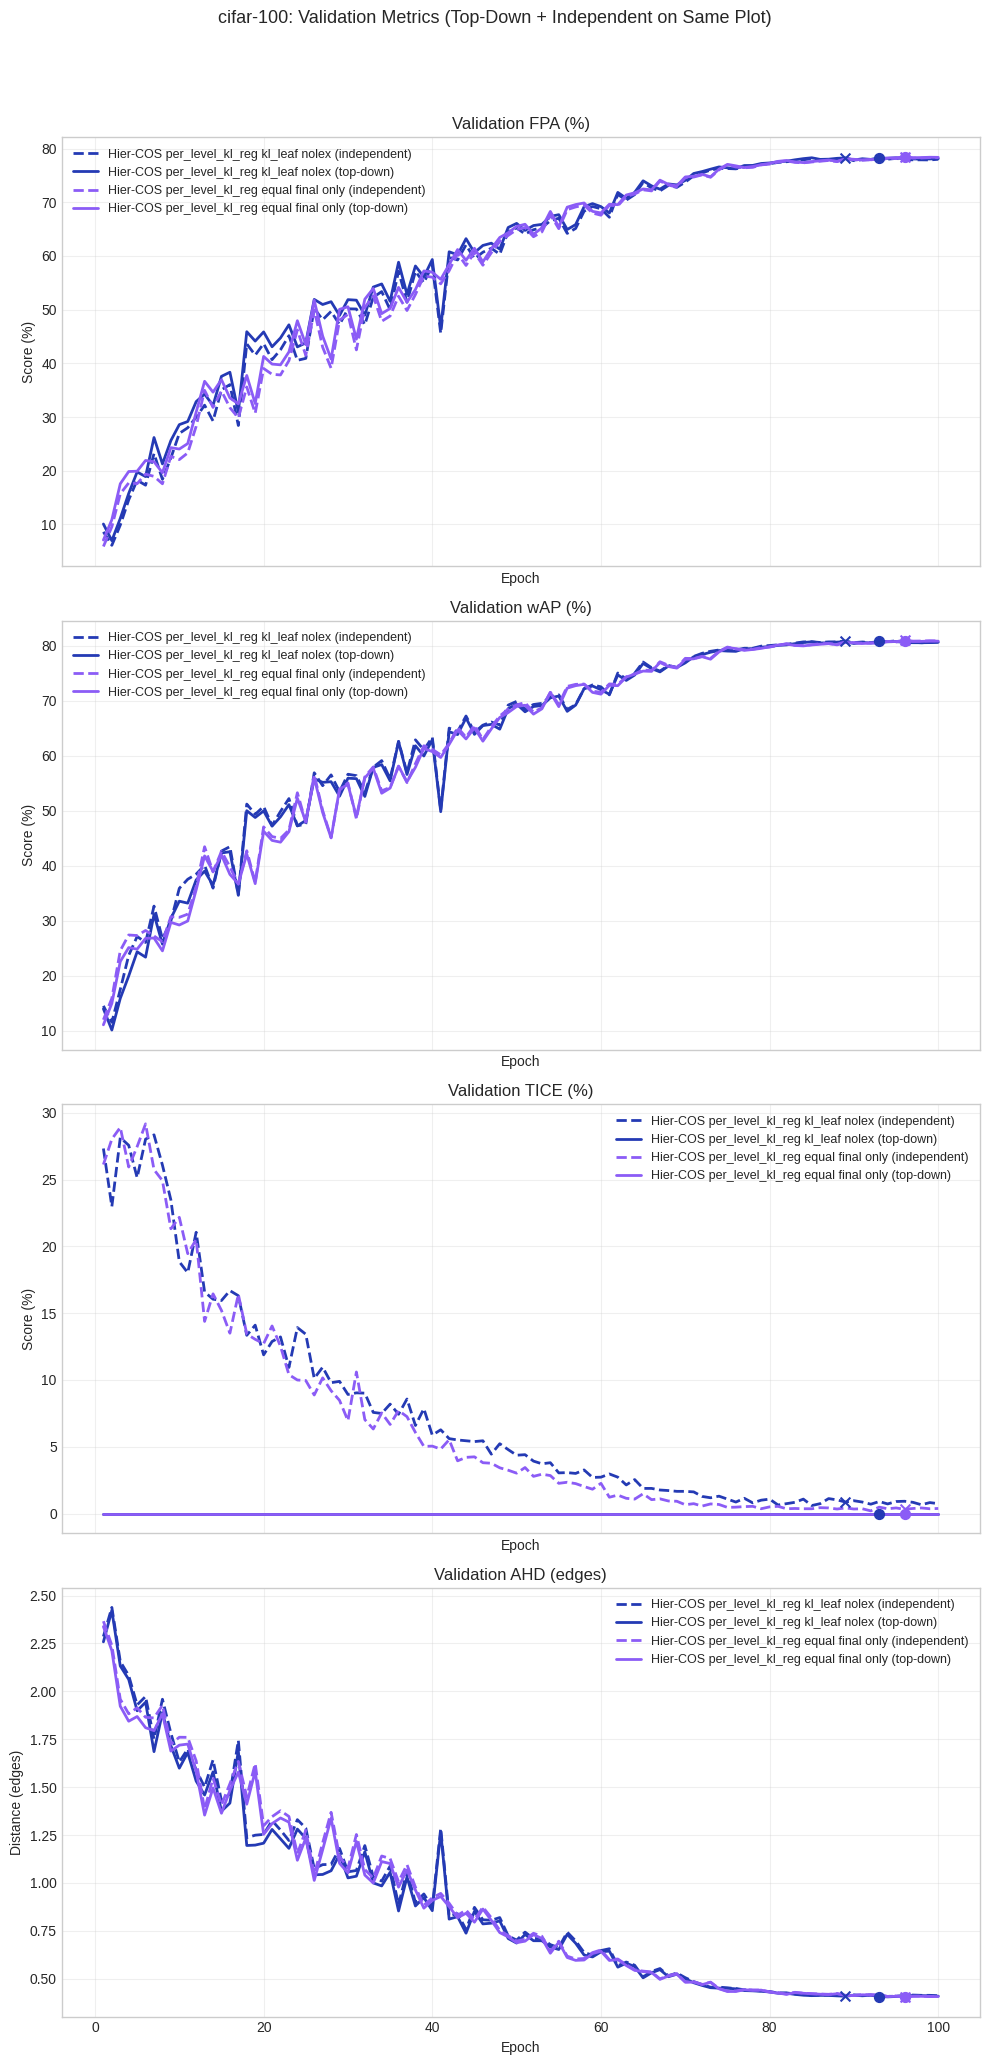

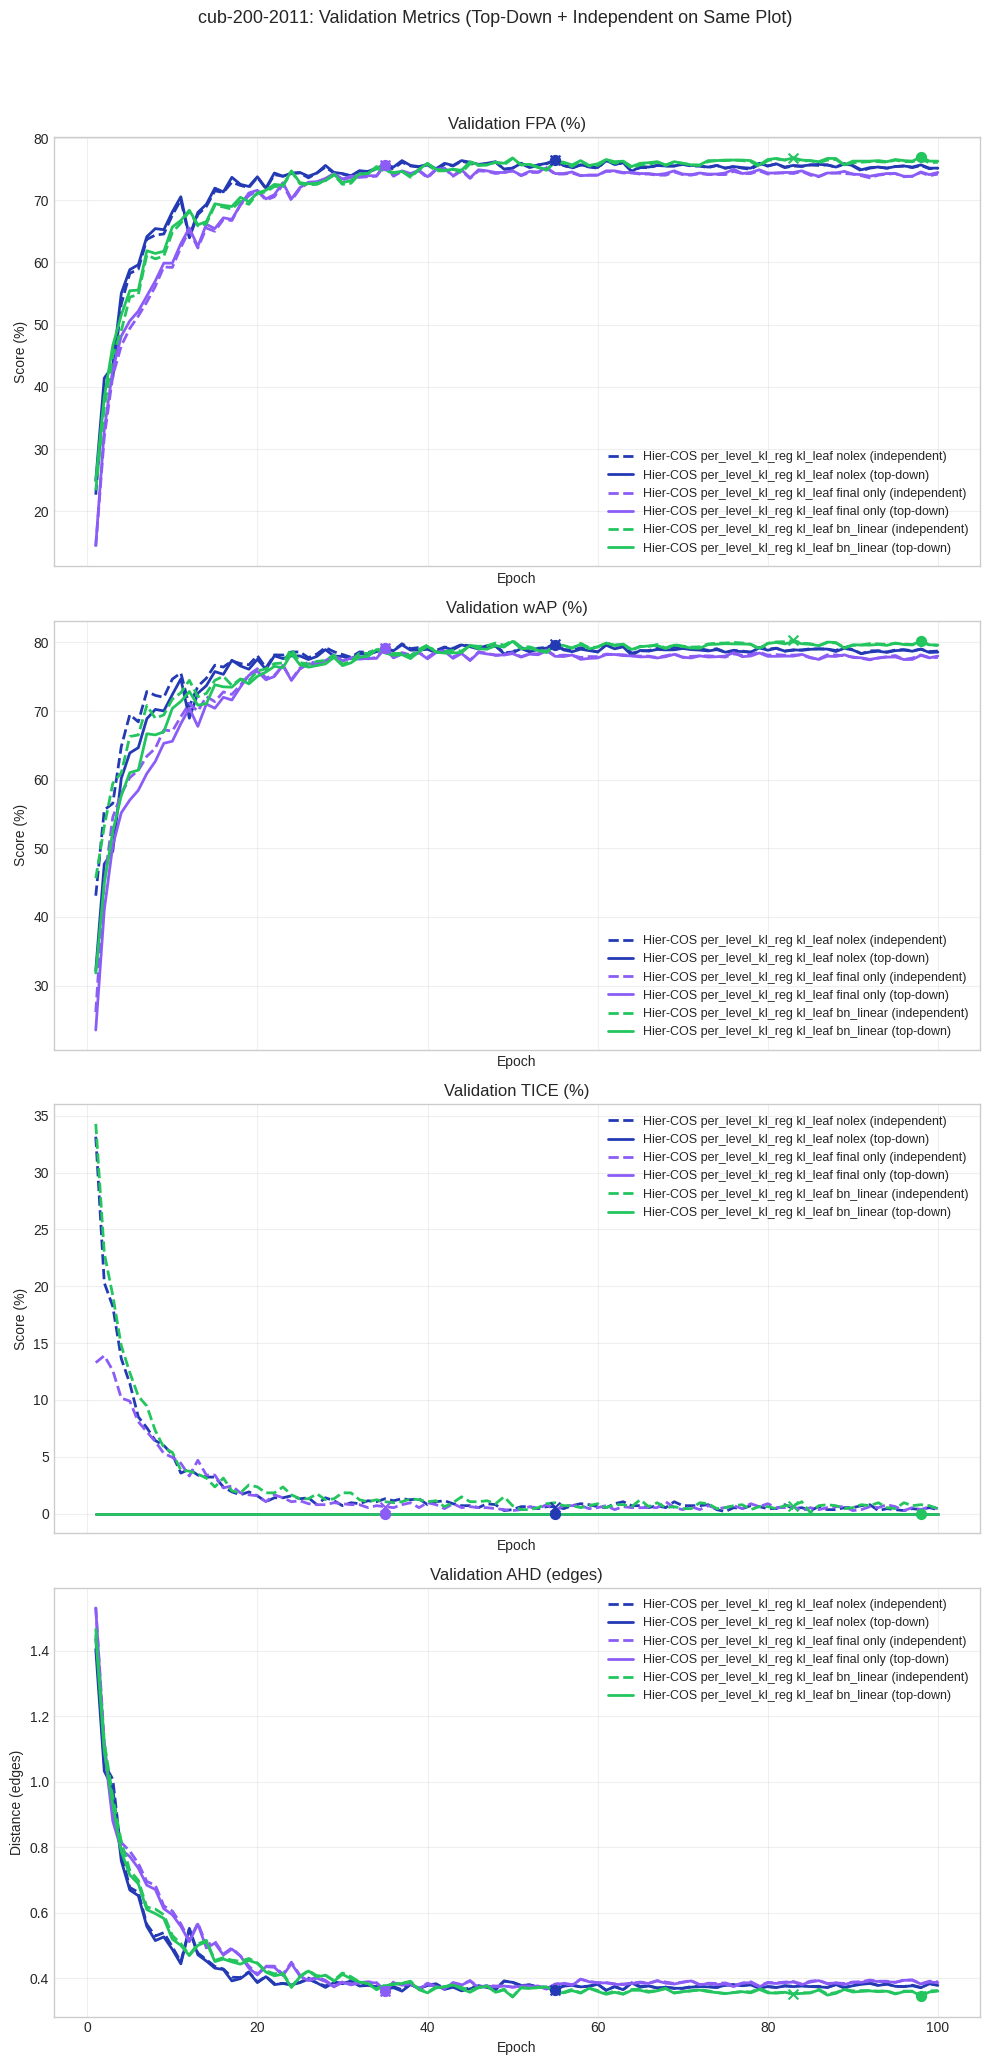

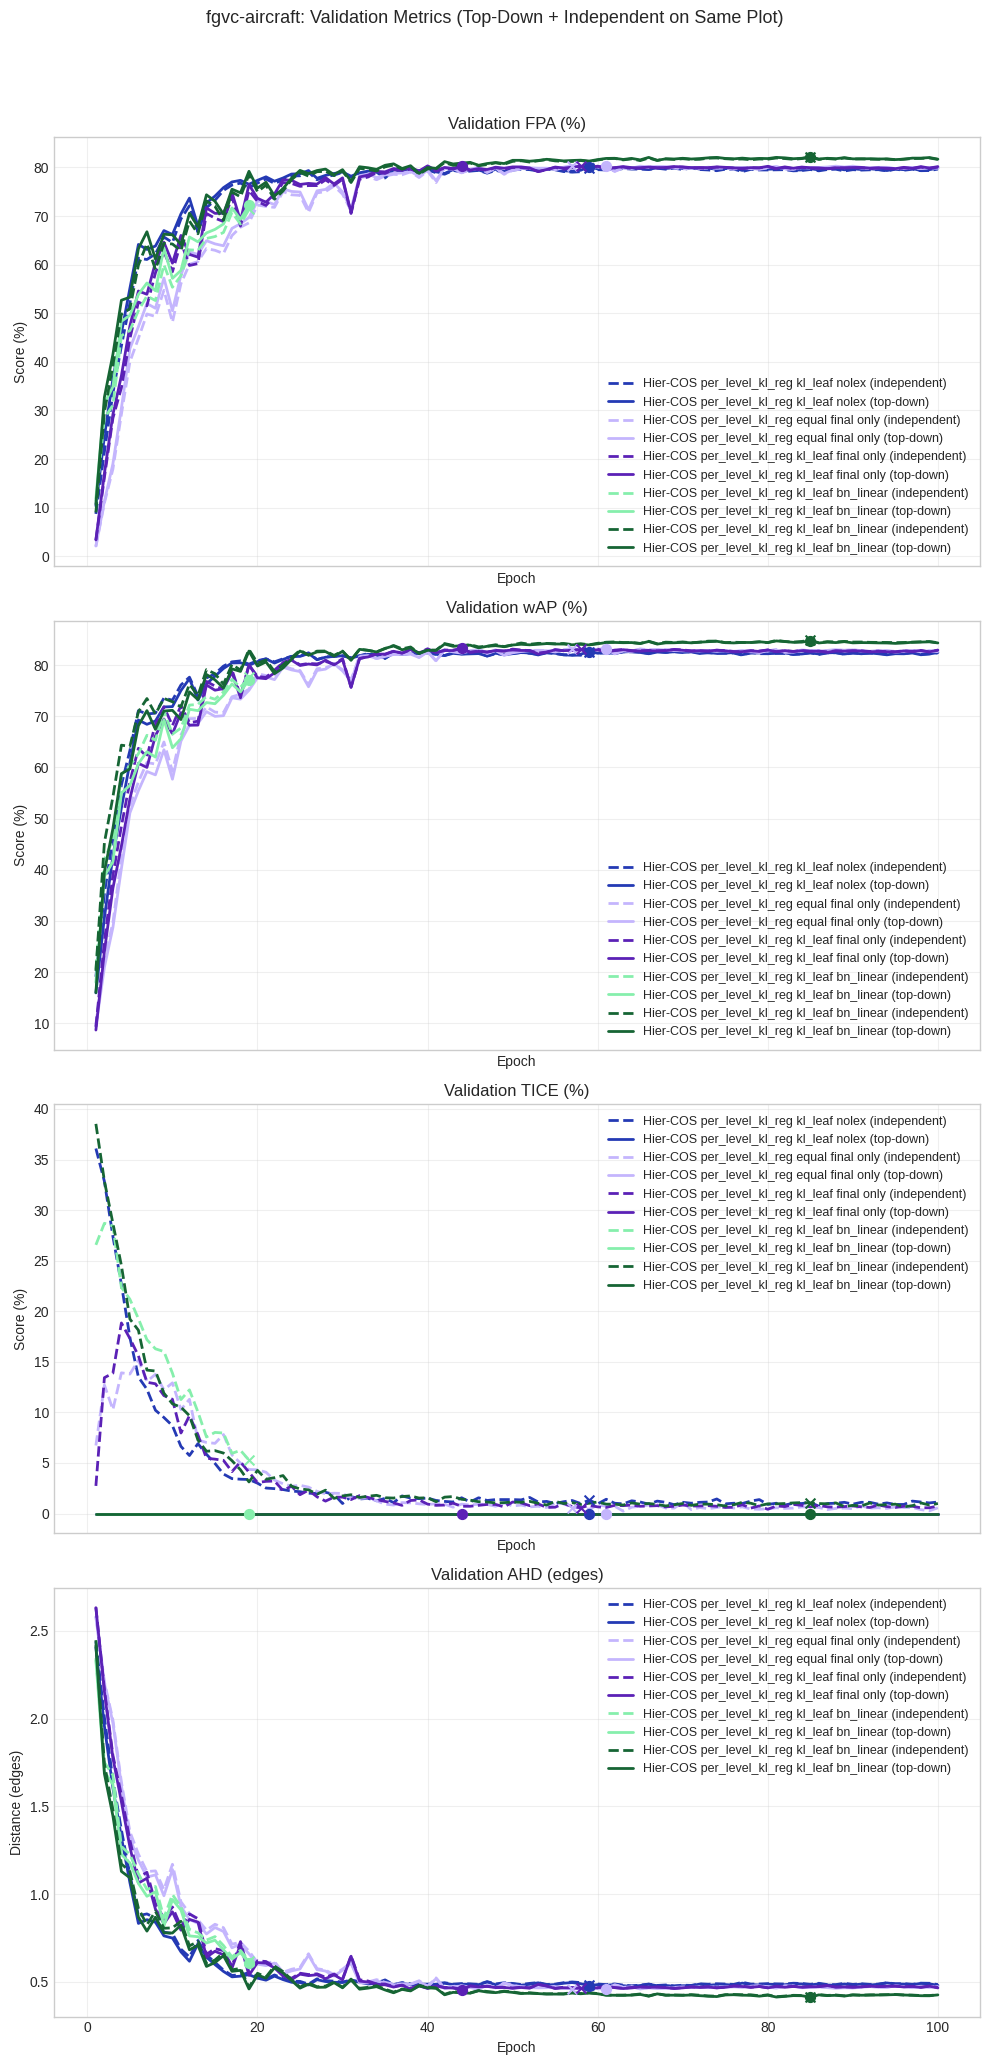

In [46]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (If Available)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha`
- `proj_constraint_strength`
- `proj_temperature`
- `proj_mode_intrinsic_soft`

For standard Hier-COS runs these keys may be absent; in that case the section prints a per-dataset skip message.


In [47]:
analysis.plot_projection_diagnostics()


[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares training losses between runs for aggregate losses (`total`, `level_ce`, `kl`, `reg`) and per-level losses (`loss_level_*`, when available).


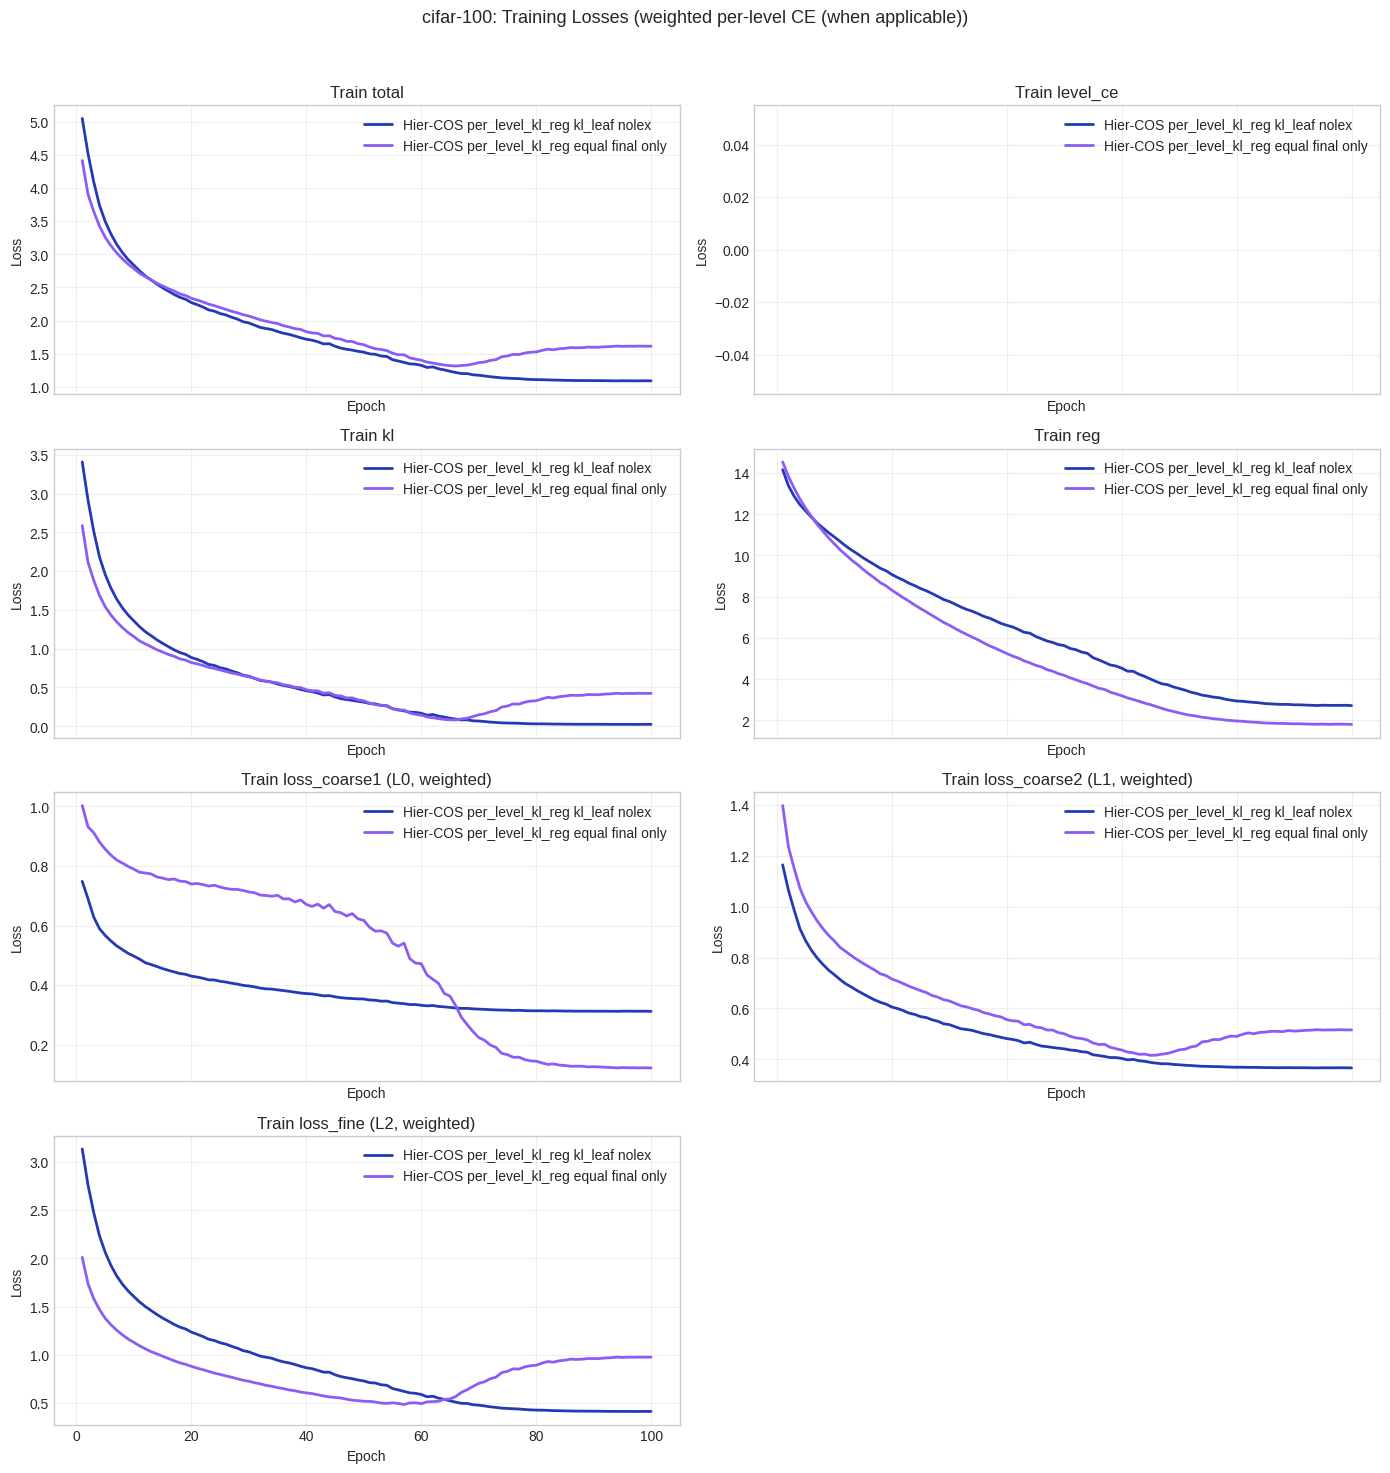

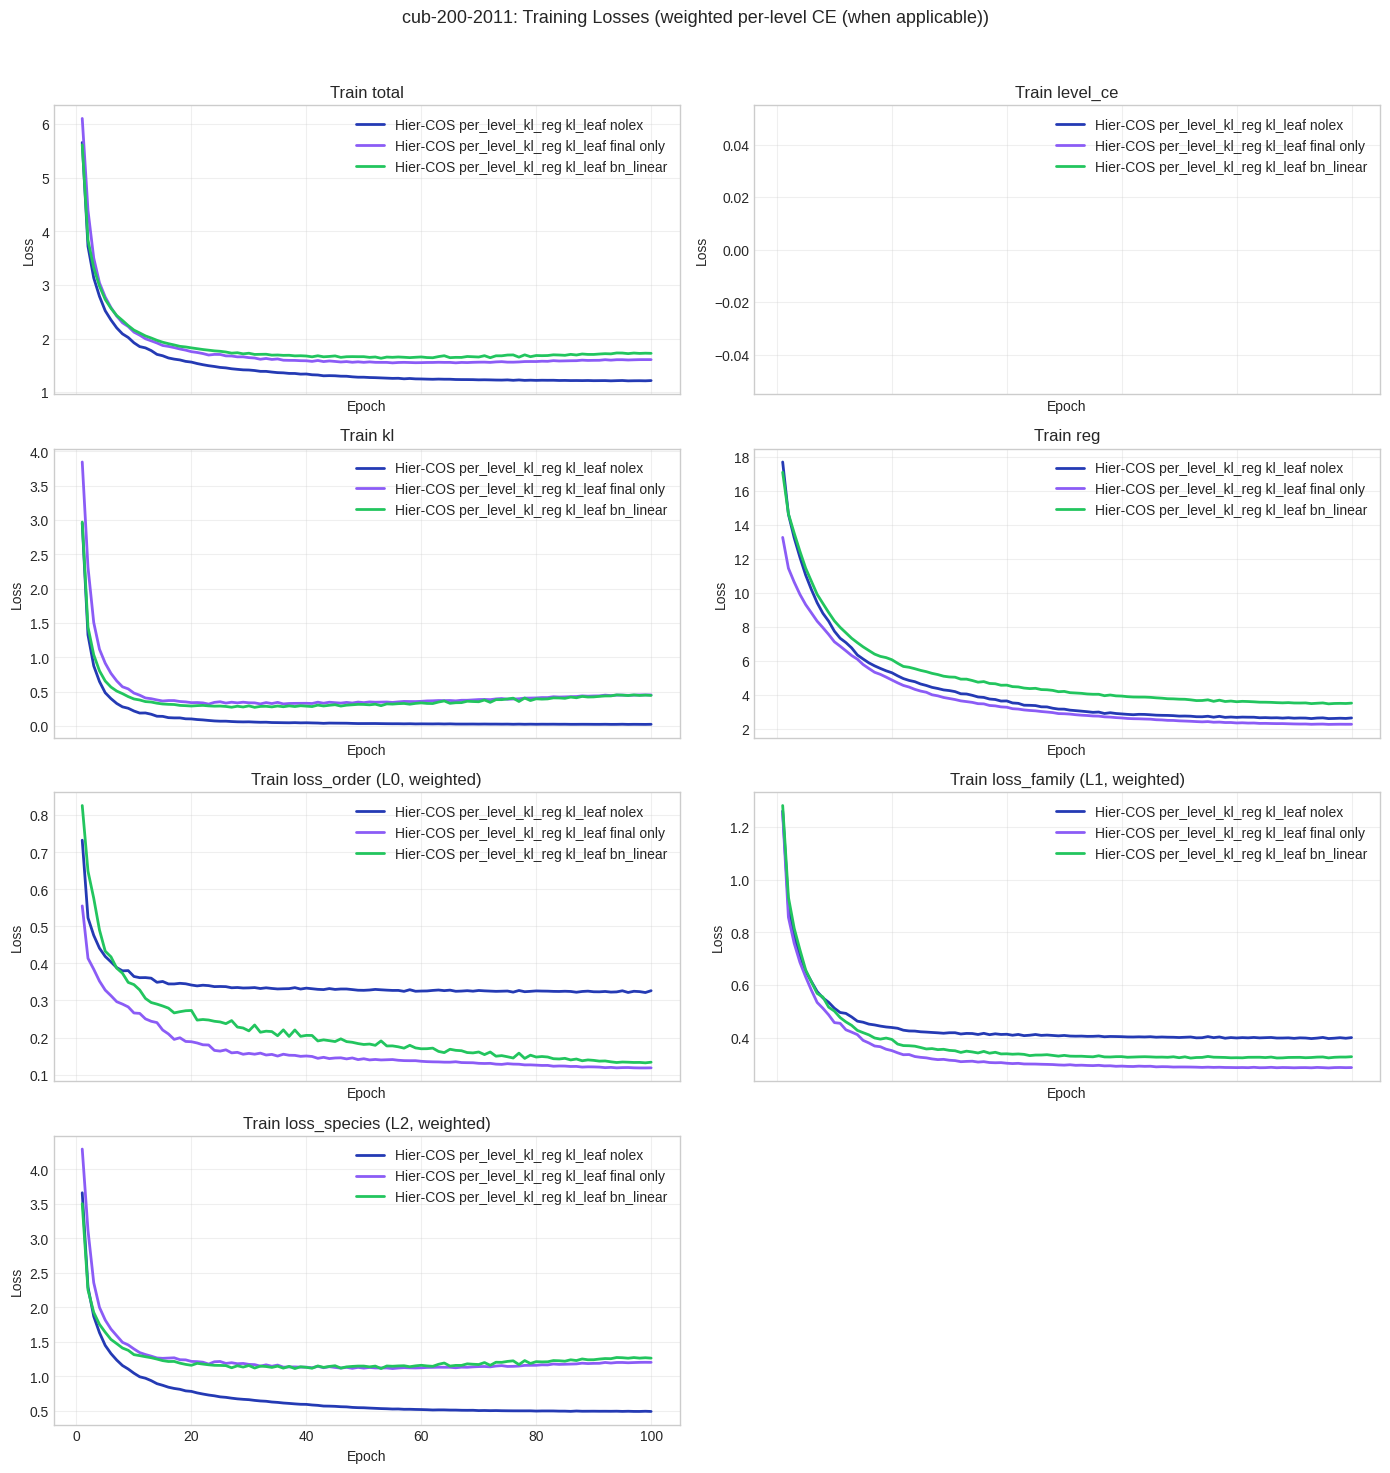

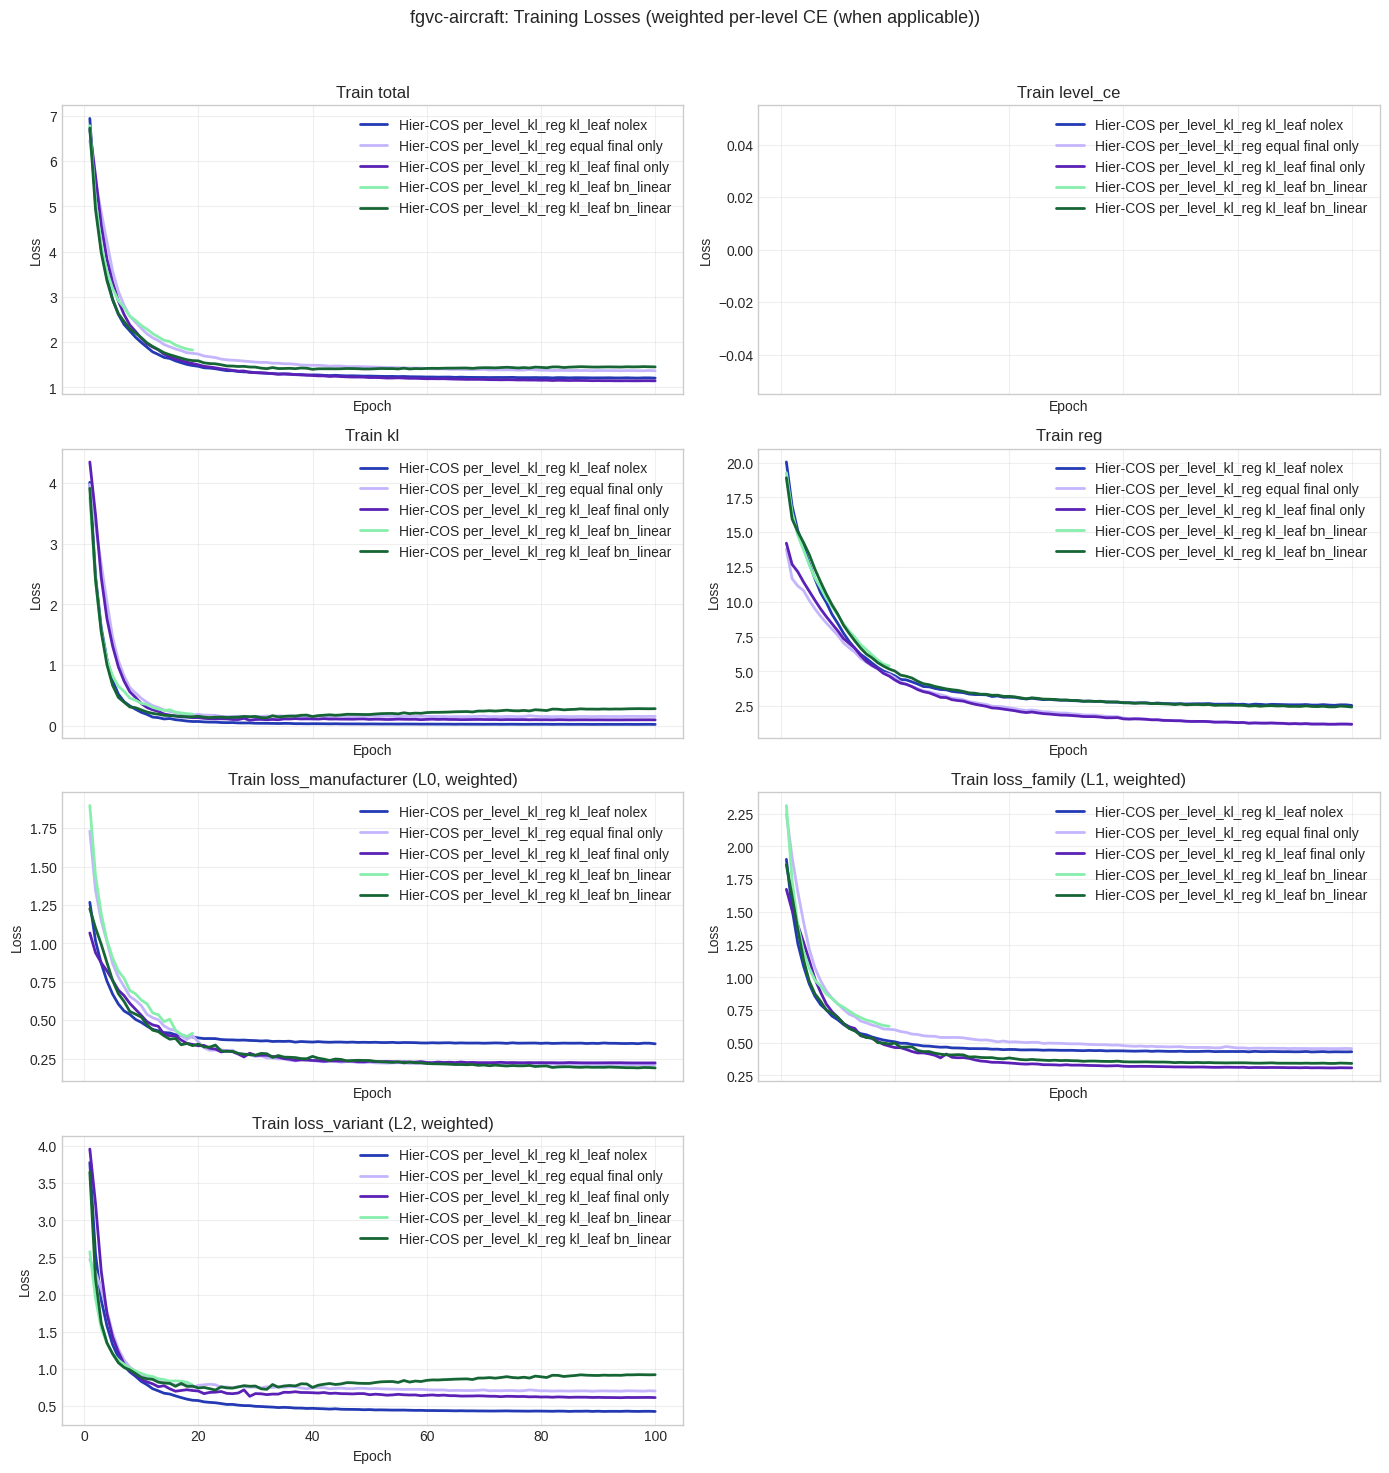

In [48]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'level_ce', 'kl', 'reg'], weighted_level_losses=WEIGHTED_LEVEL_LOSSES)


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



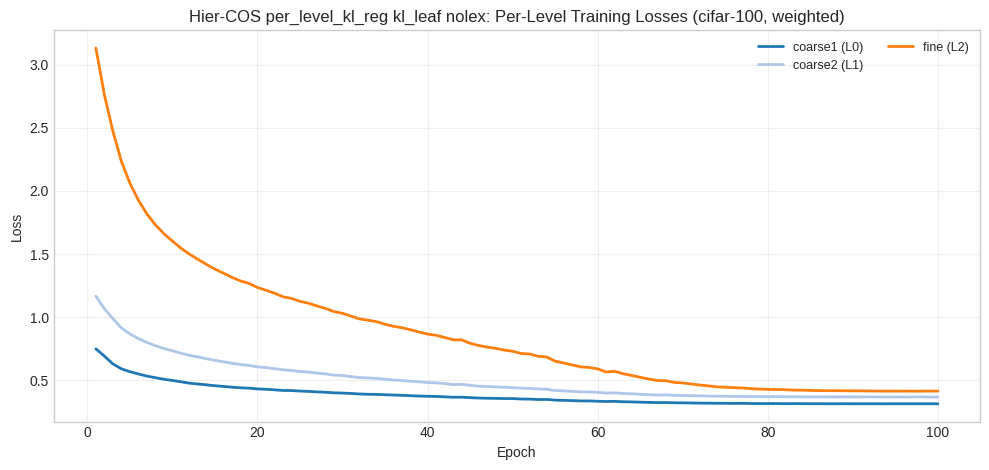

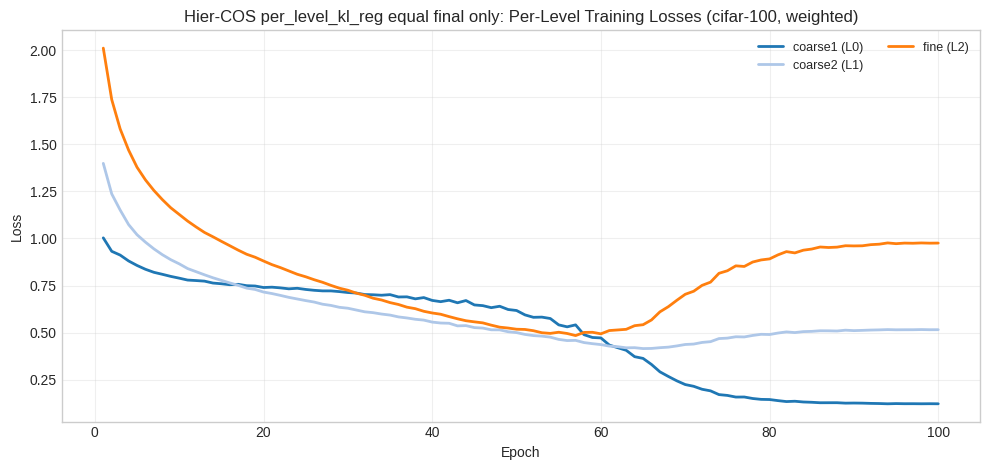

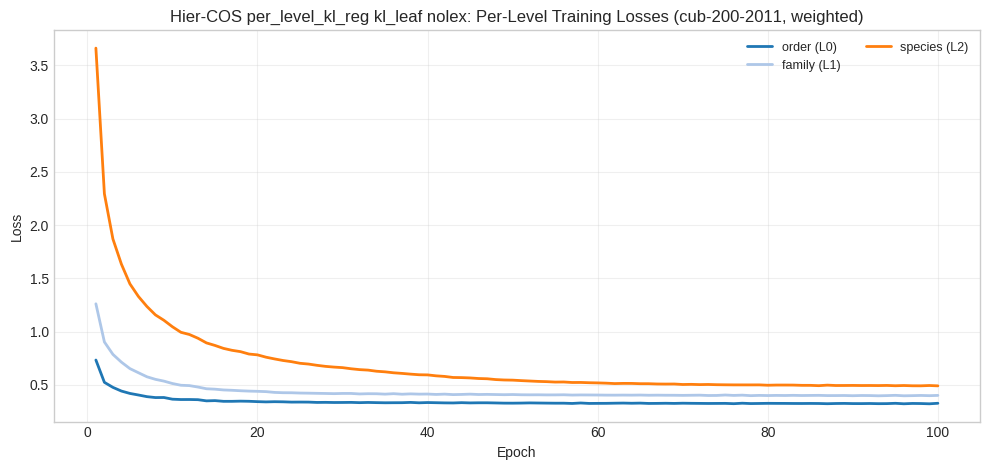

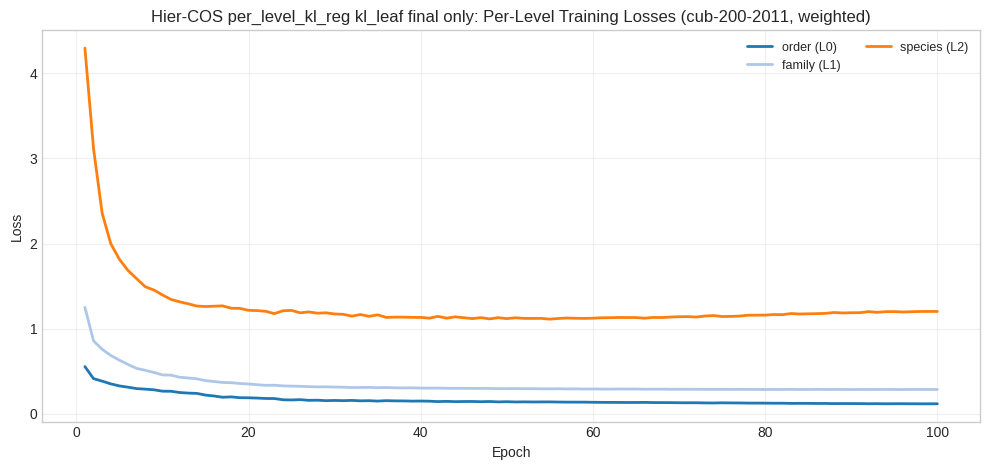

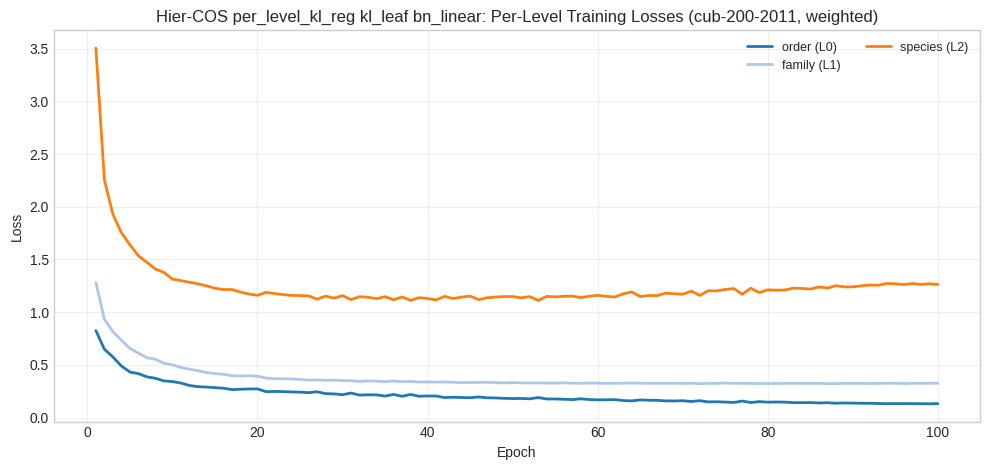

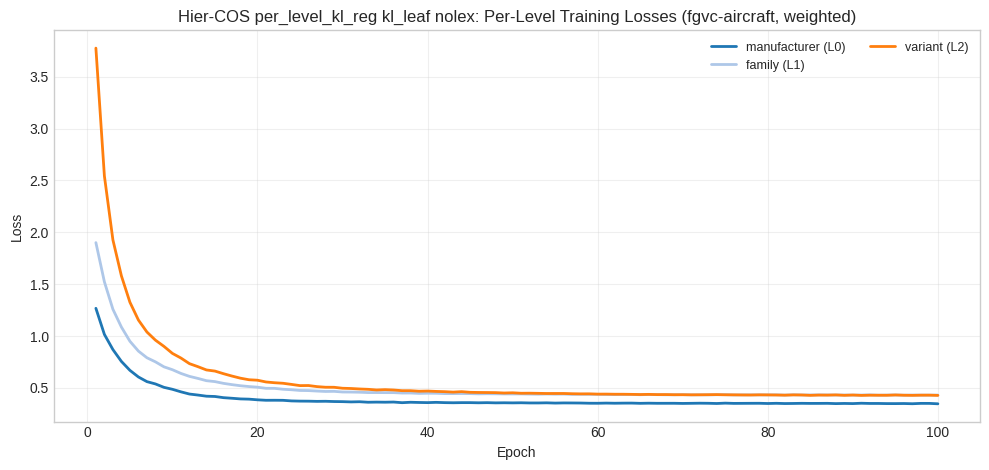

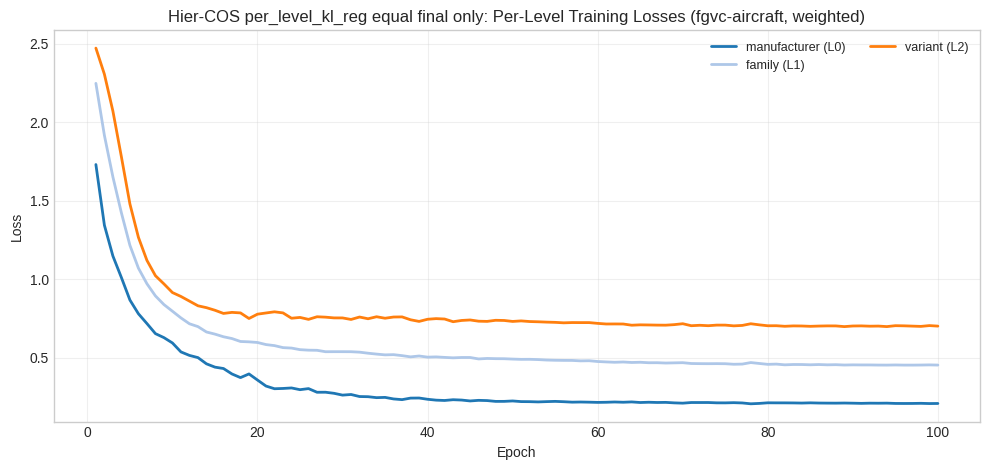

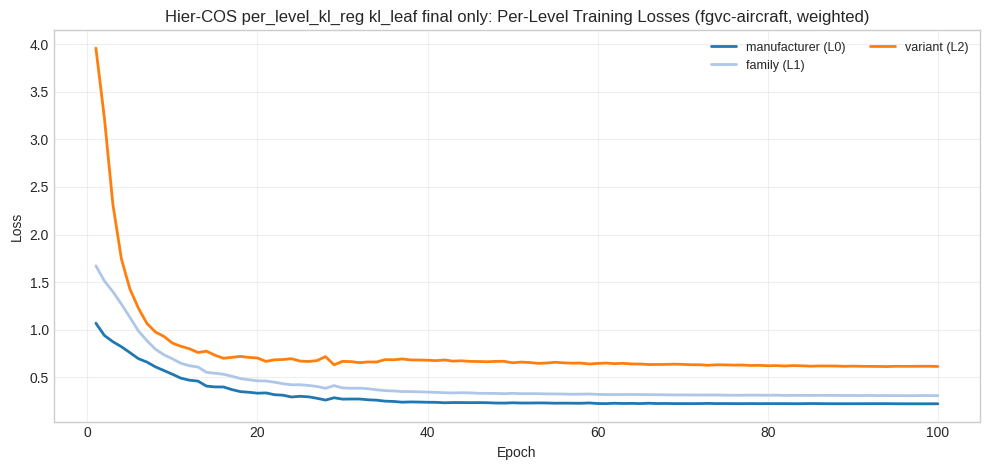

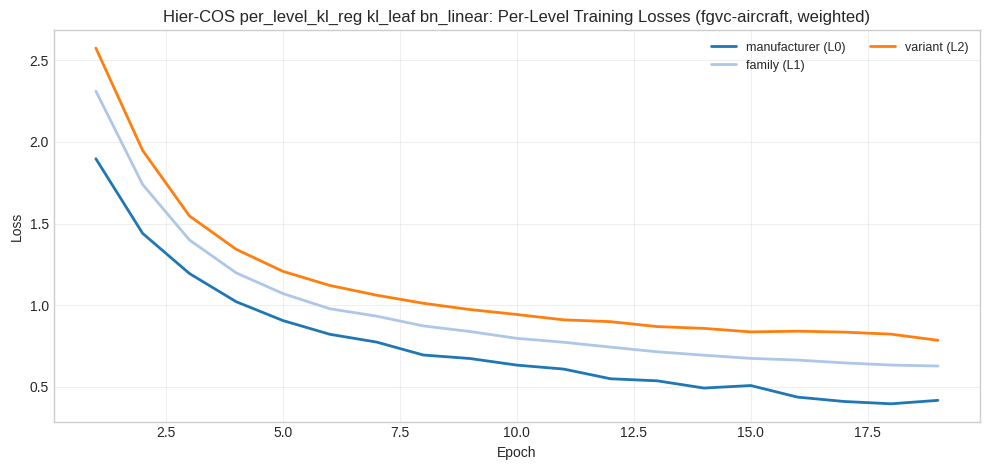

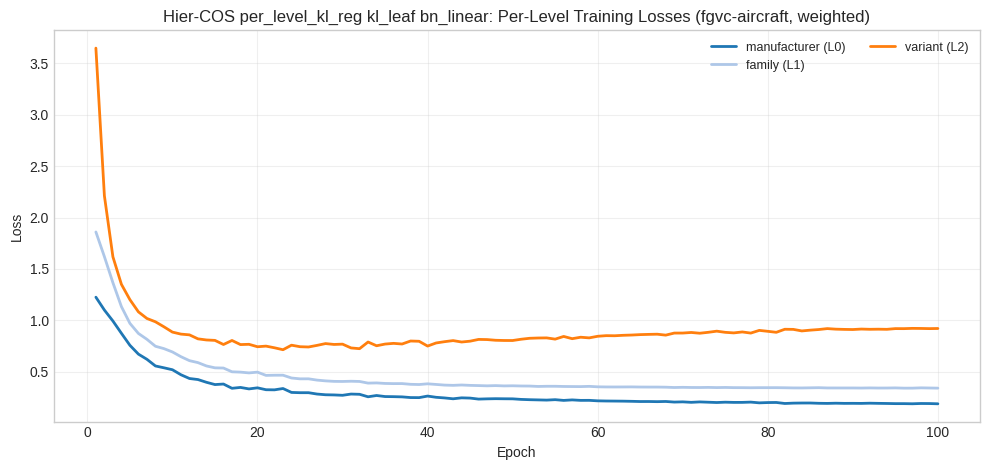

In [49]:
analysis.plot_per_run_per_level_training_losses(weighted_level_losses=WEIGHTED_LEVEL_LOSSES)


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and optional projection diagnostics stored in `train_metrics` for each epoch.

For Hier-COS, many of these metrics are available only in CE/diagnostic-focused runs. If unavailable, corresponding plots are skipped automatically.


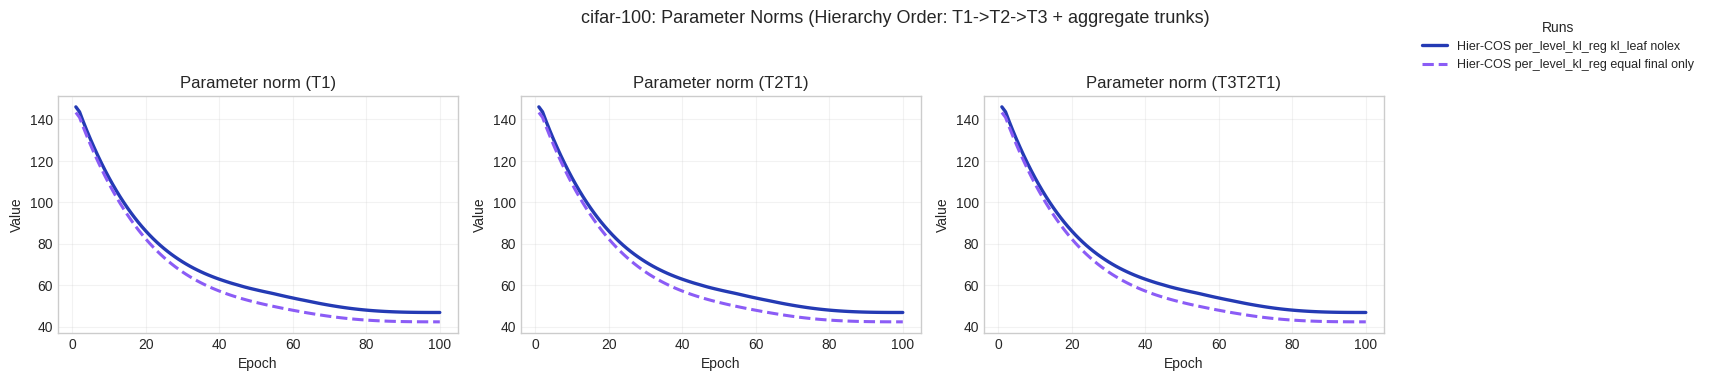

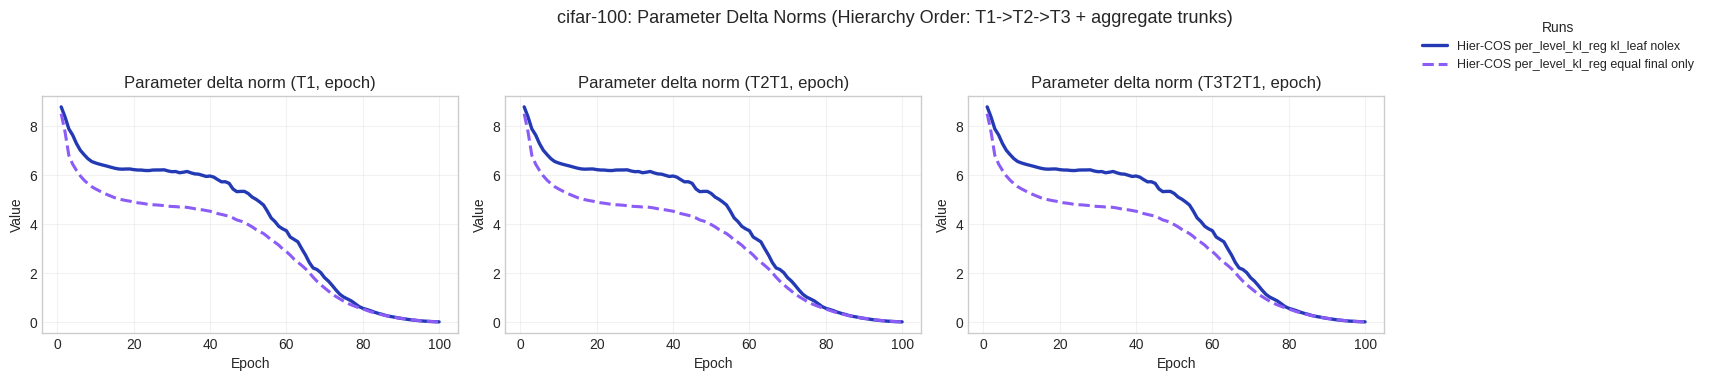

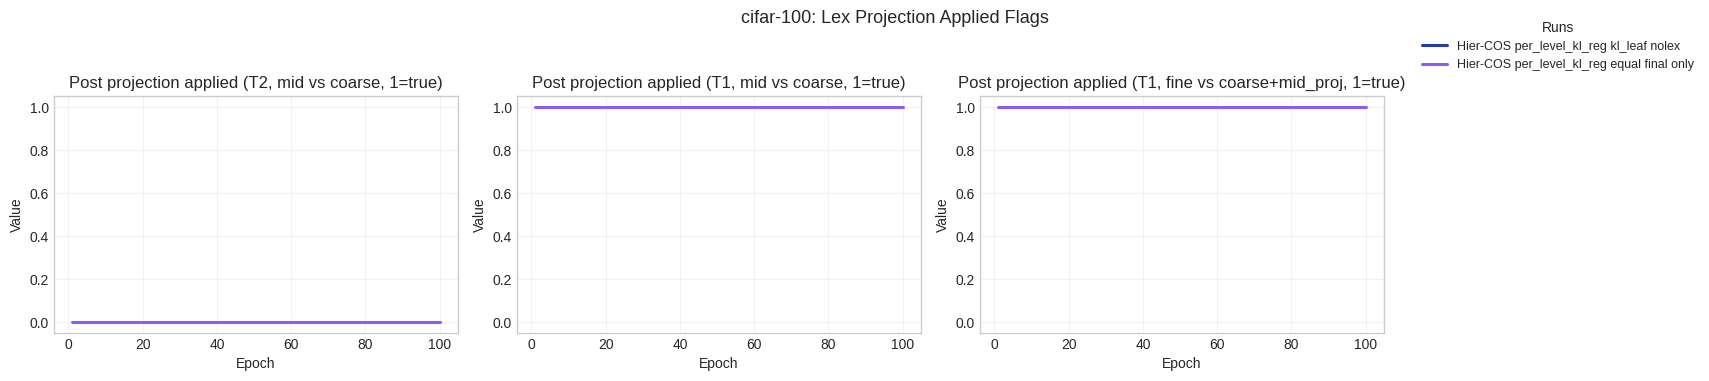

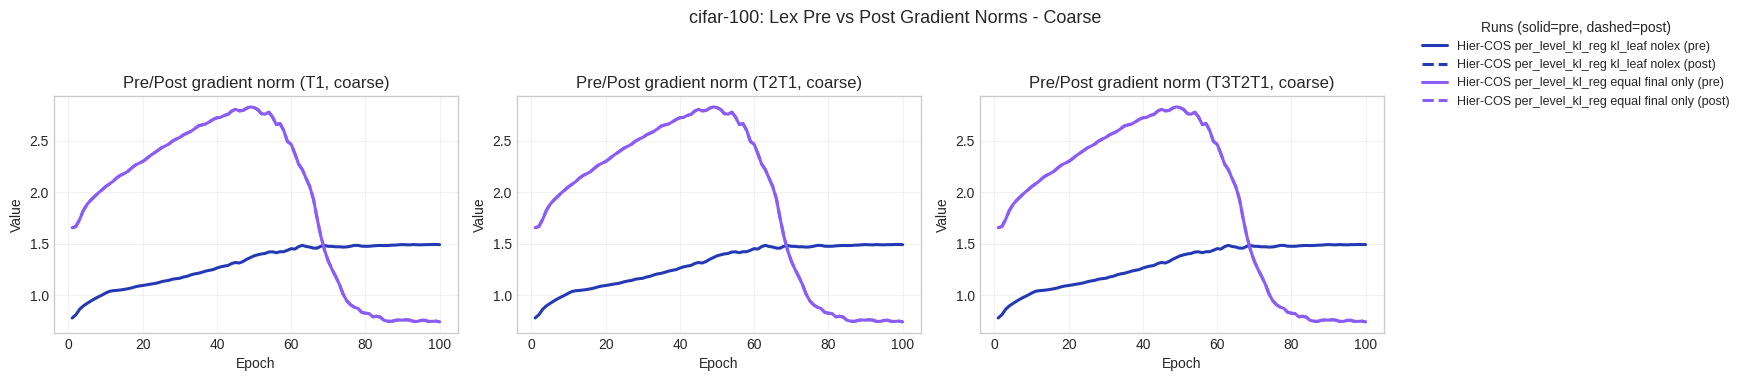

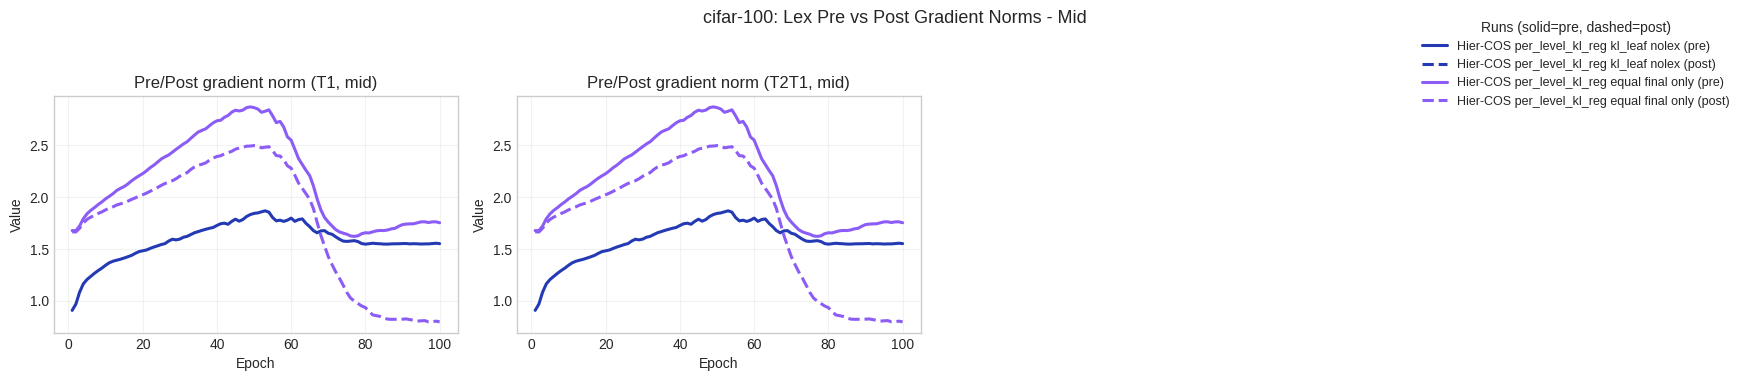

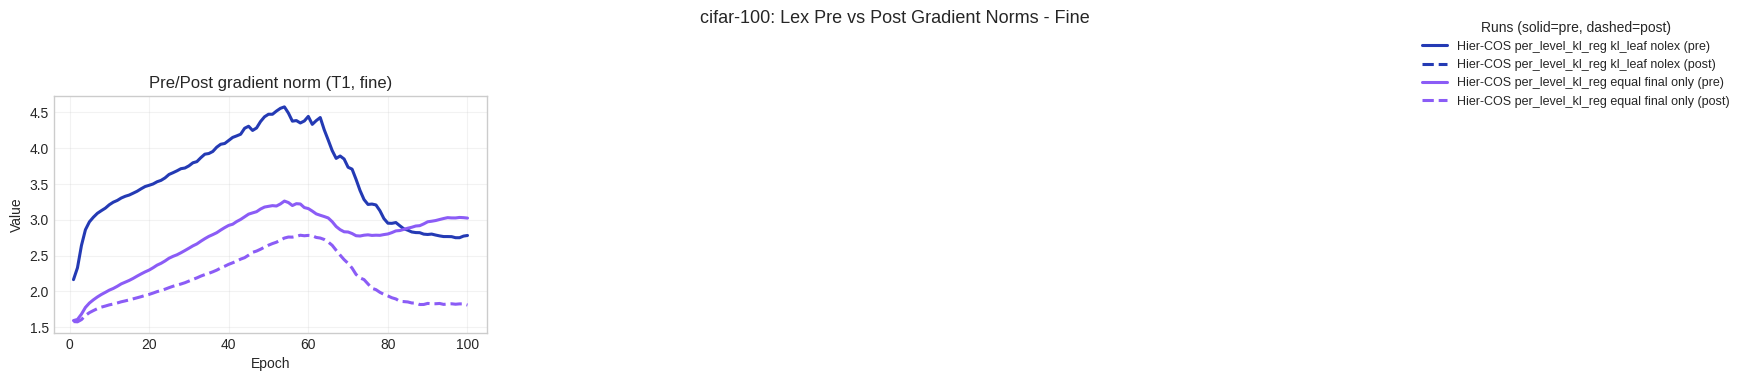

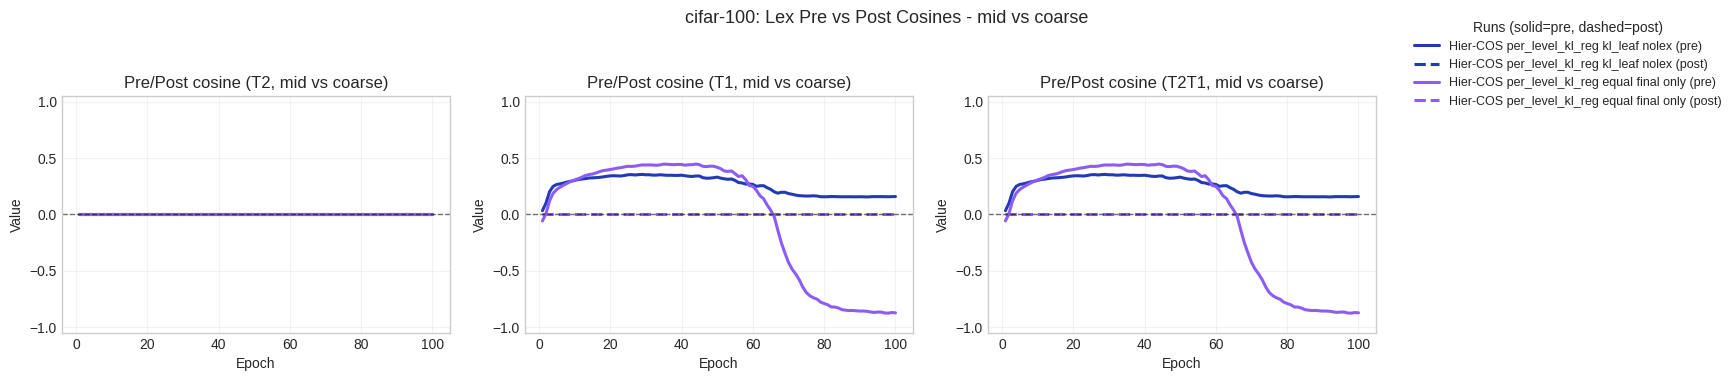

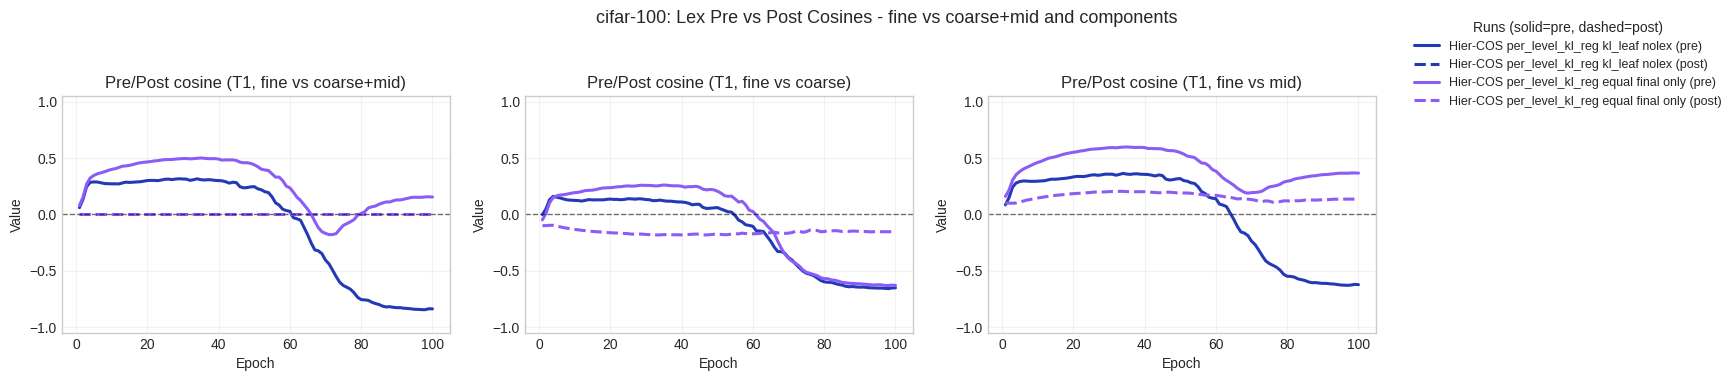

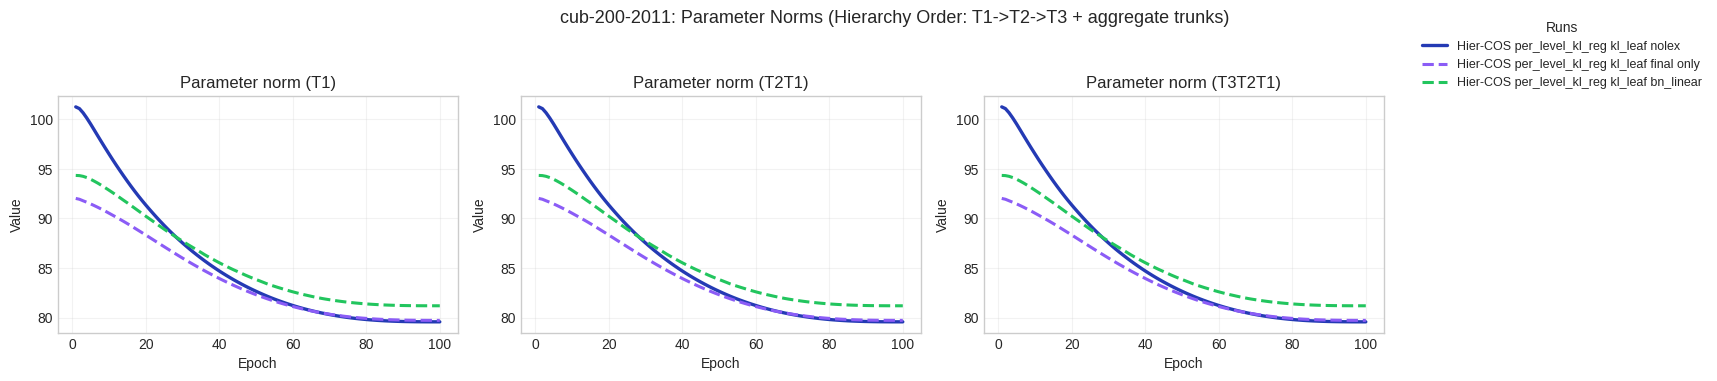

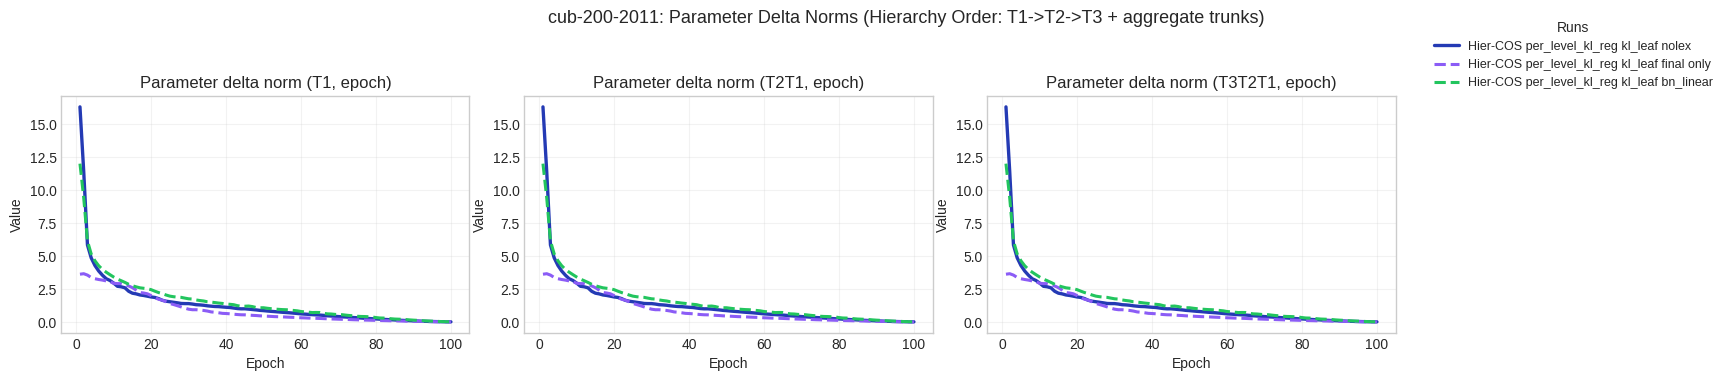

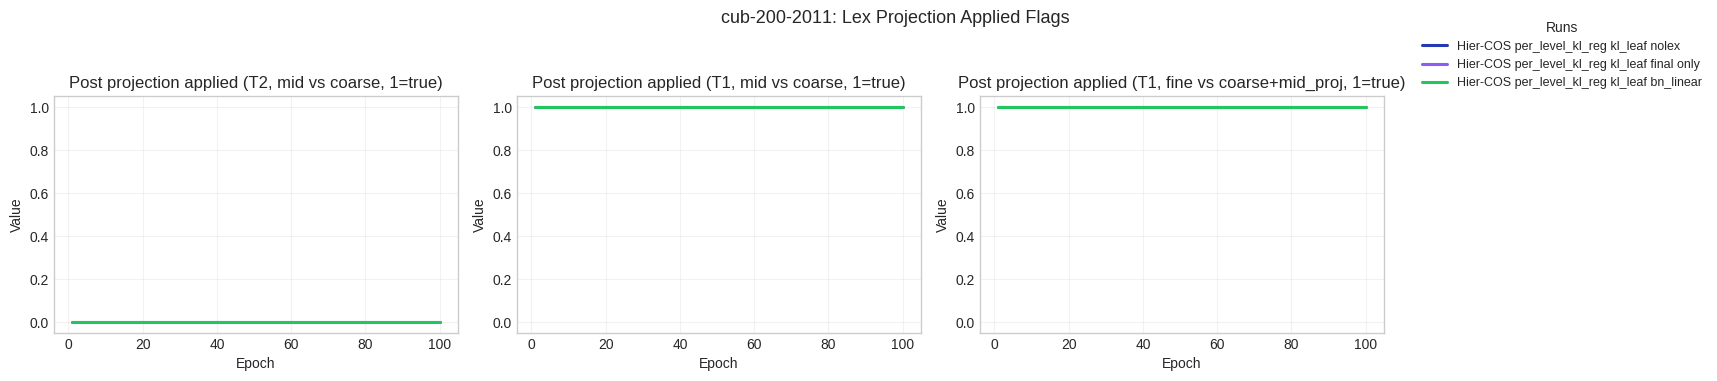

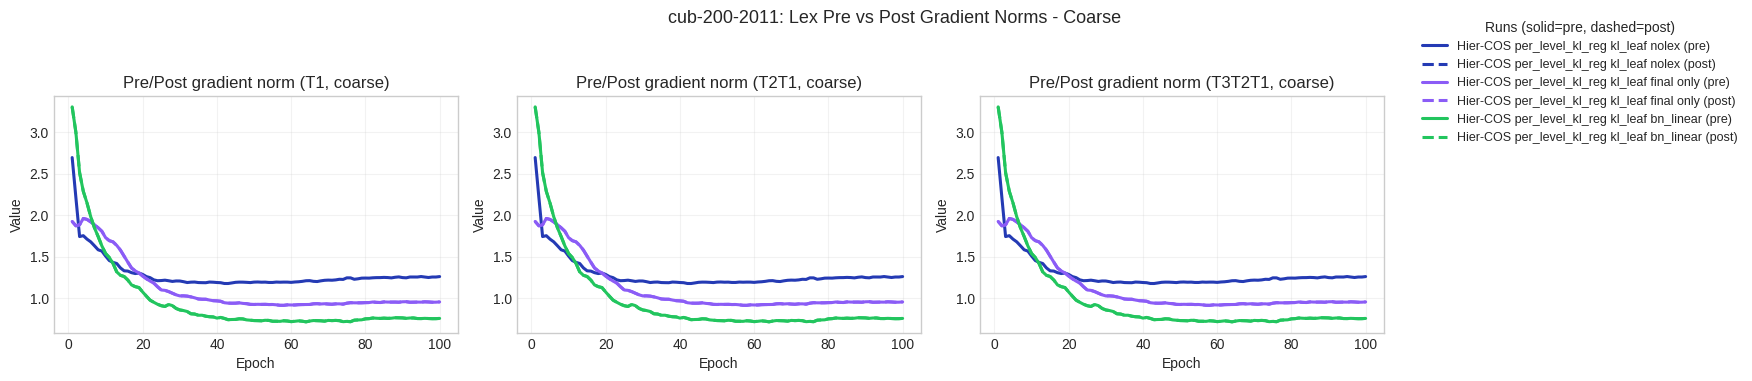

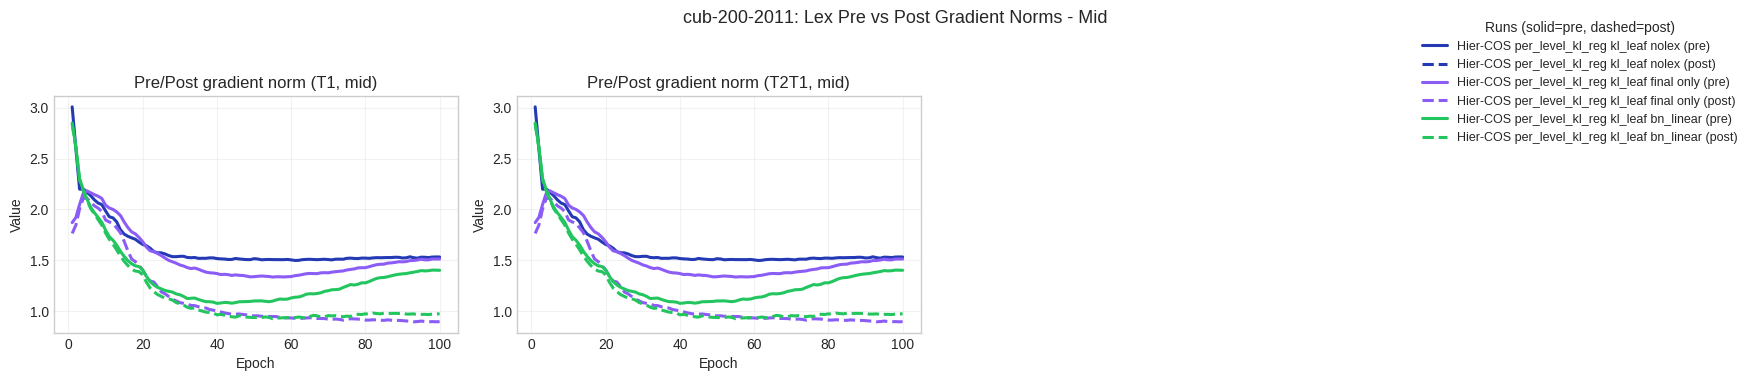

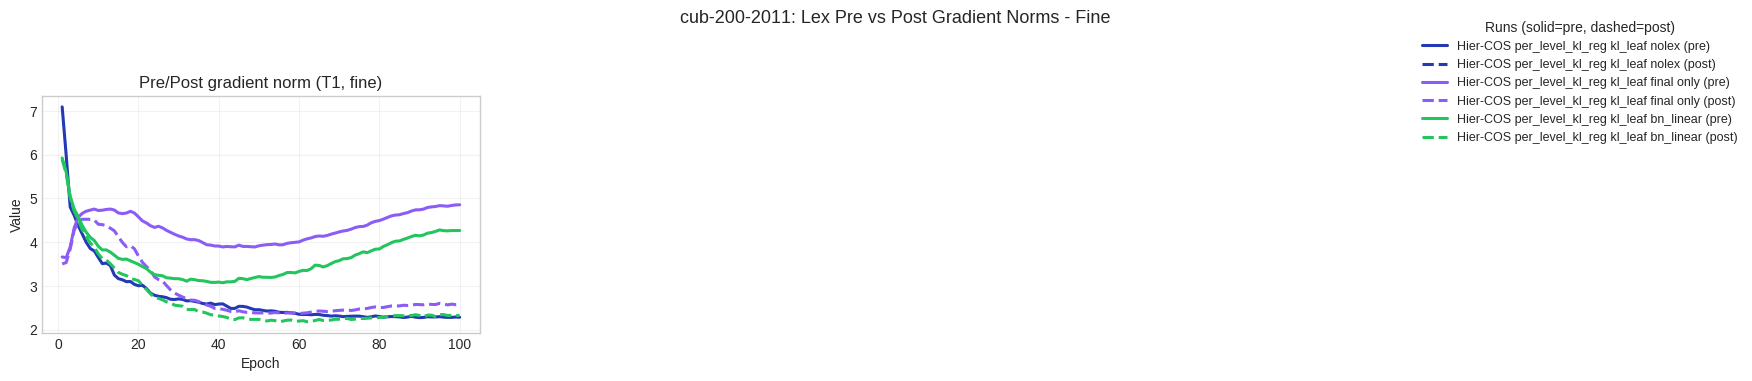

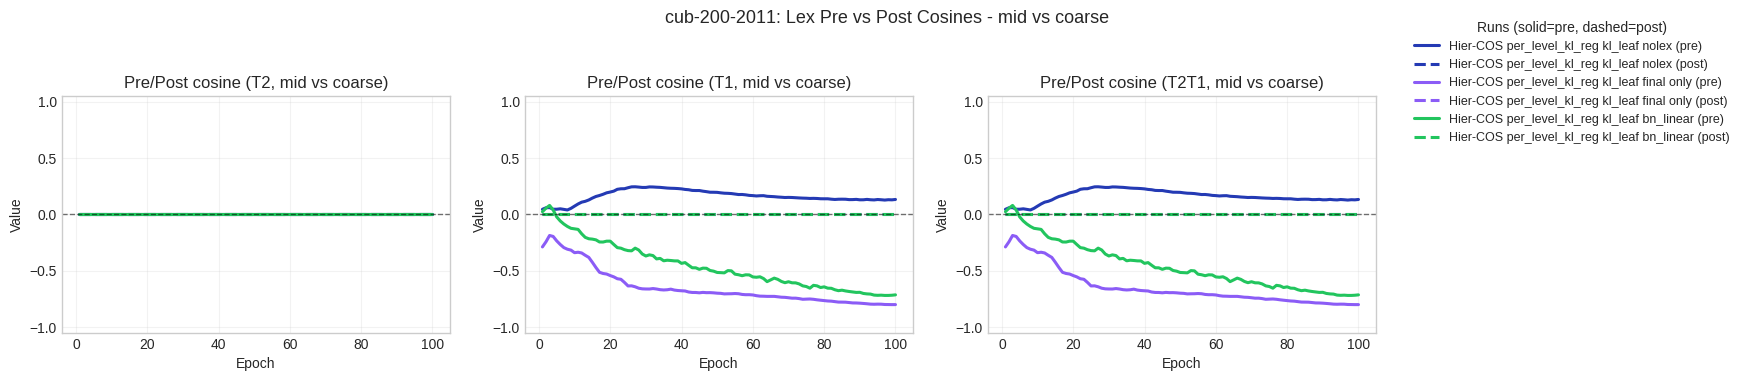

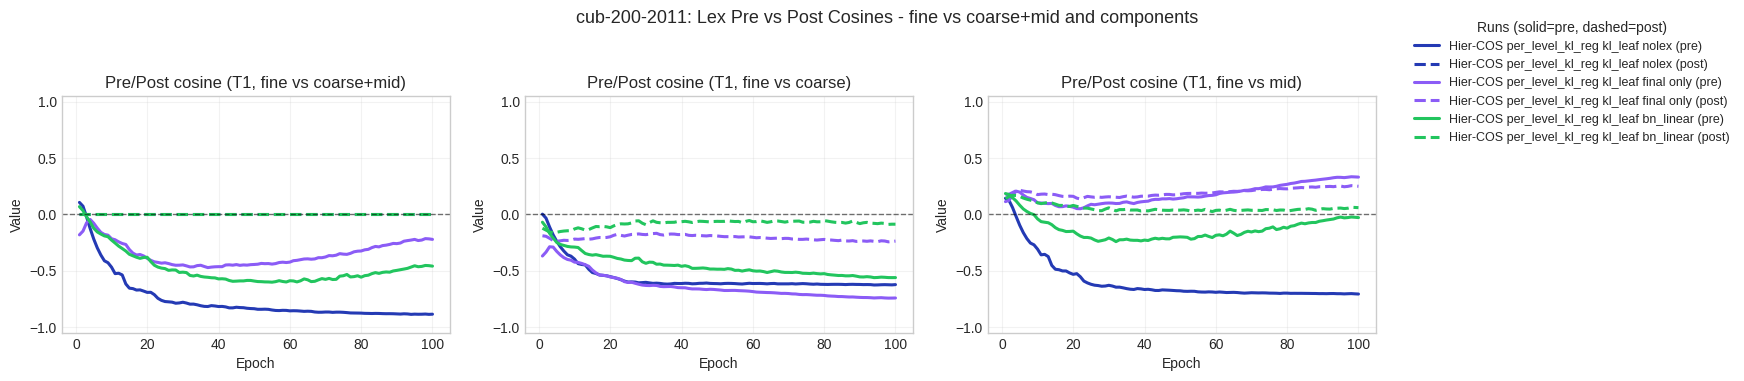

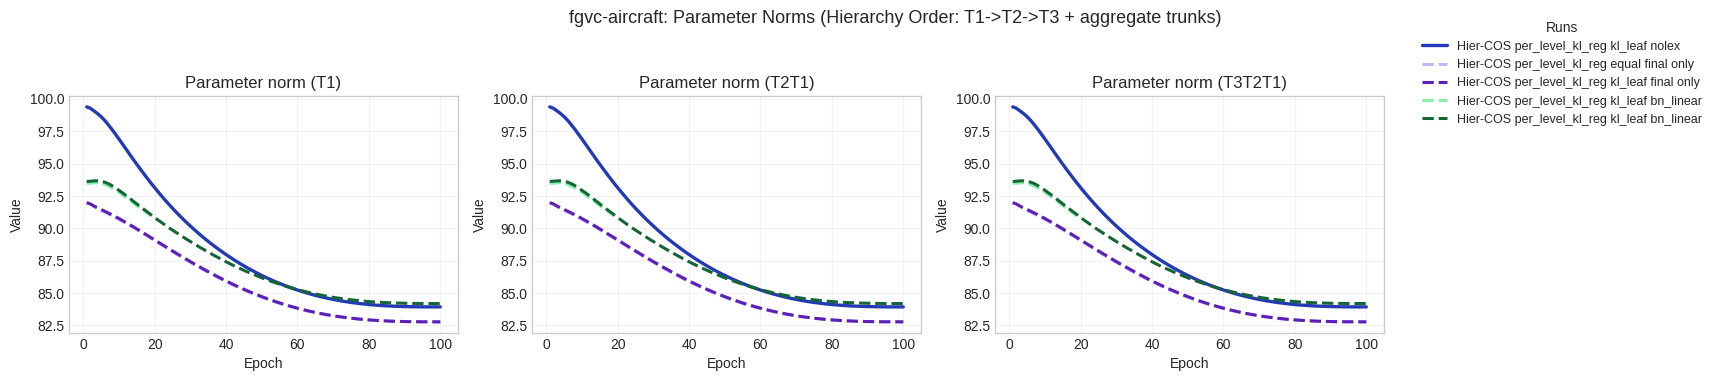

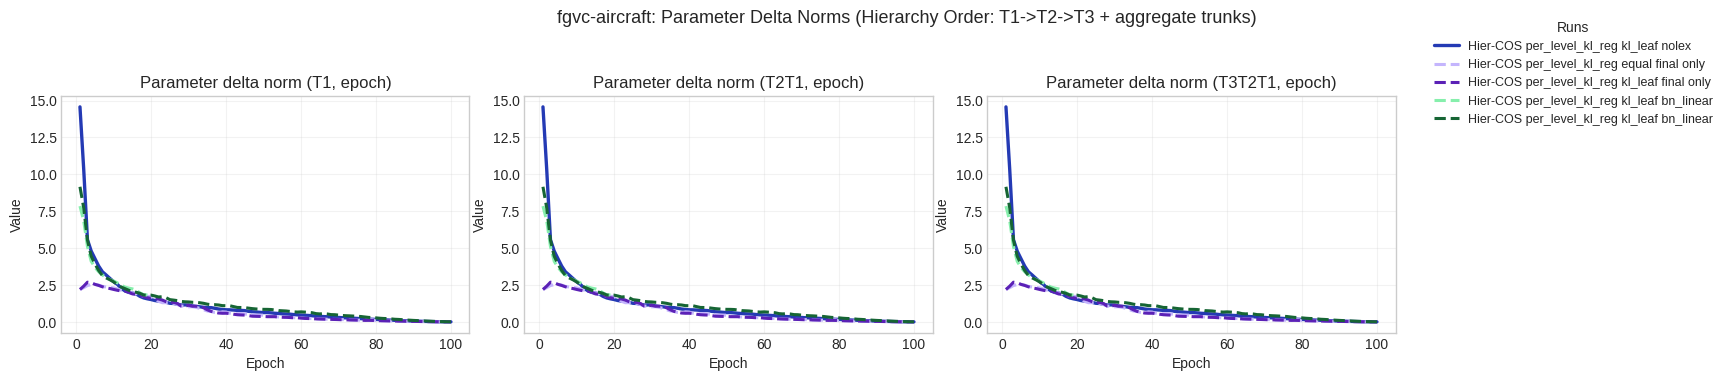

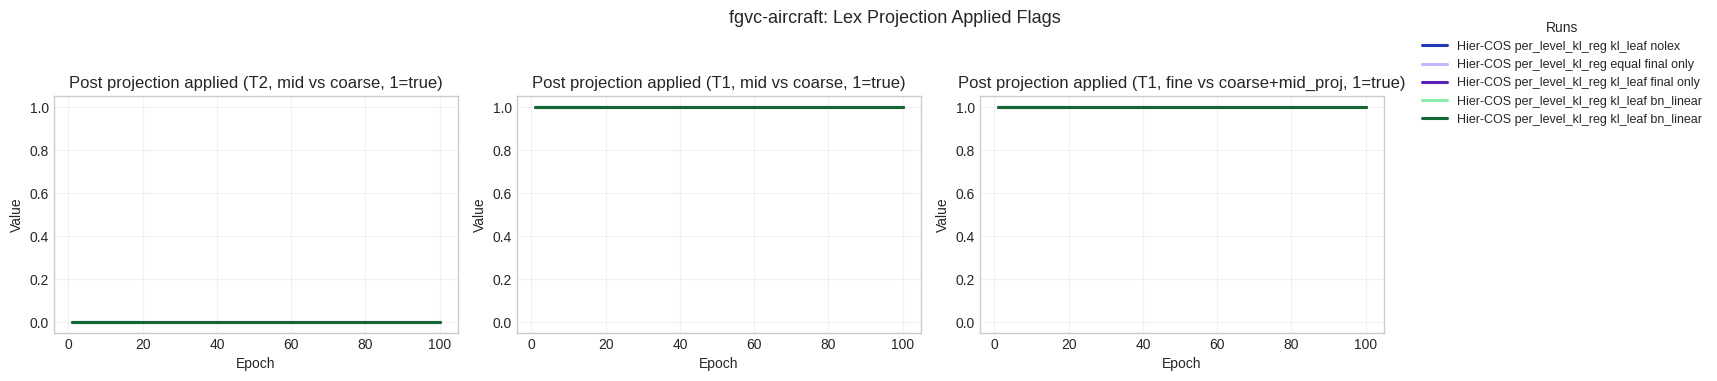

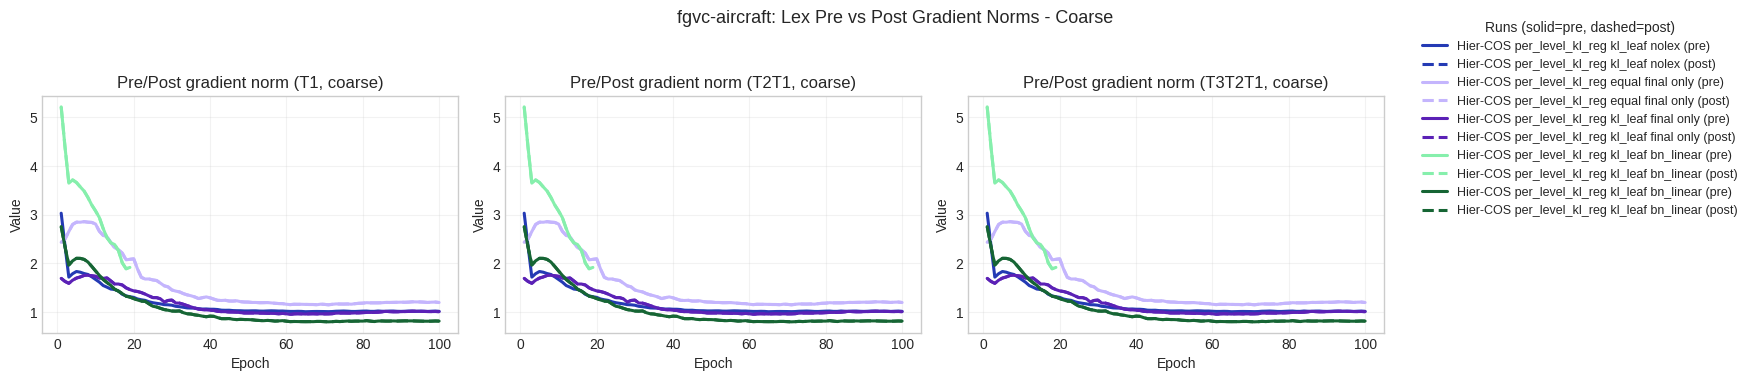

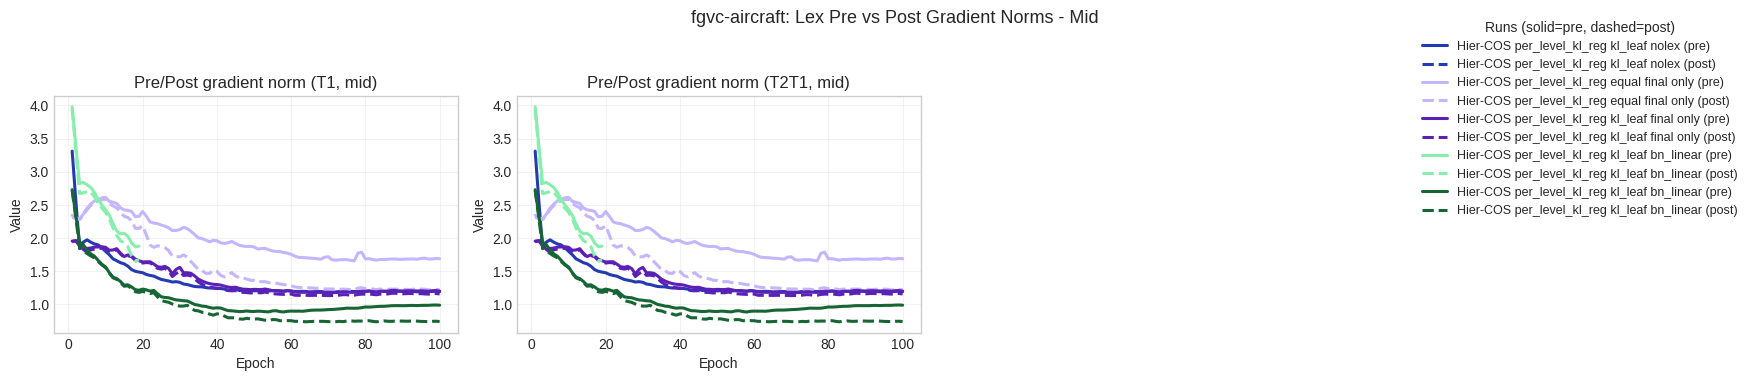

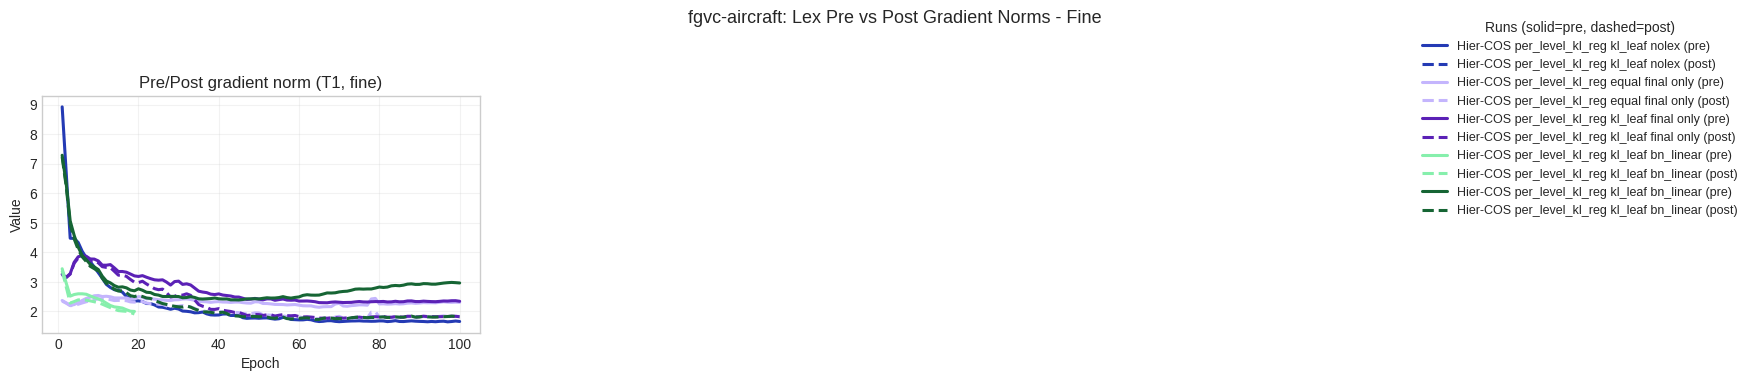

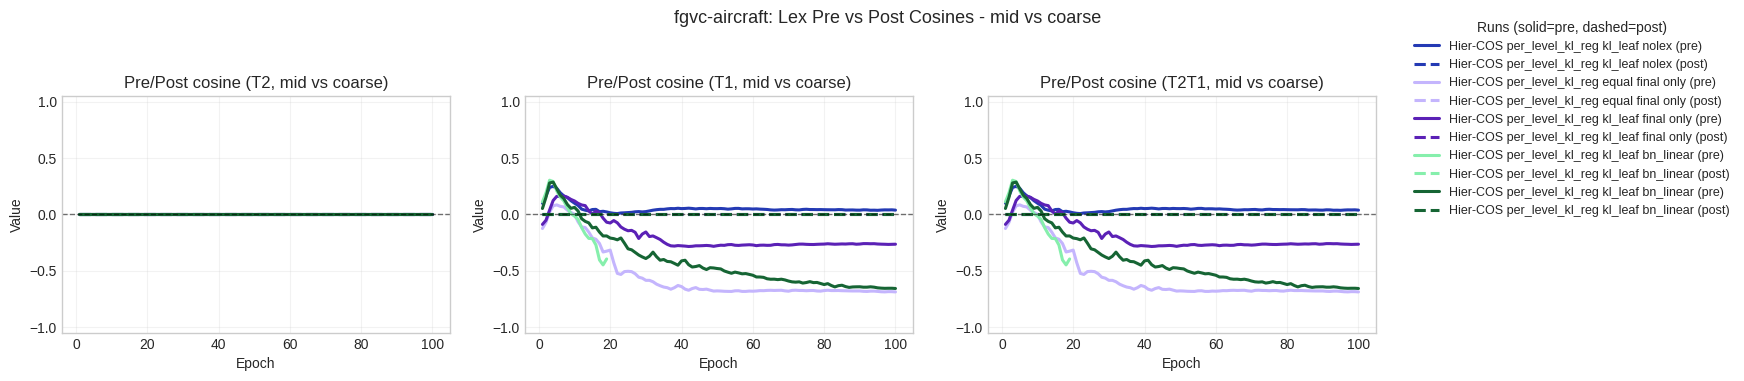

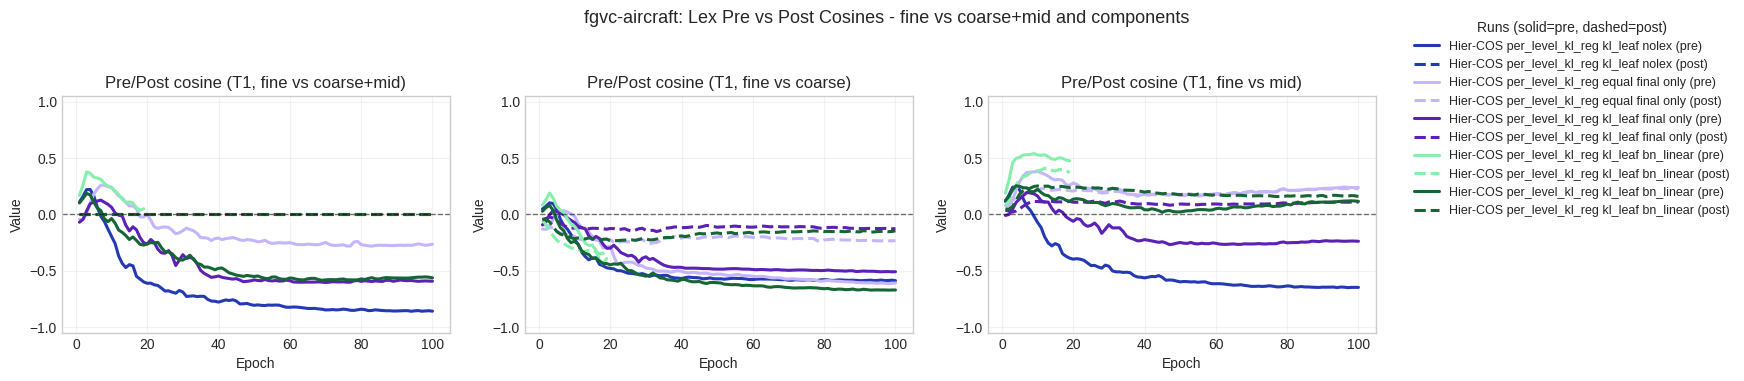

In [50]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

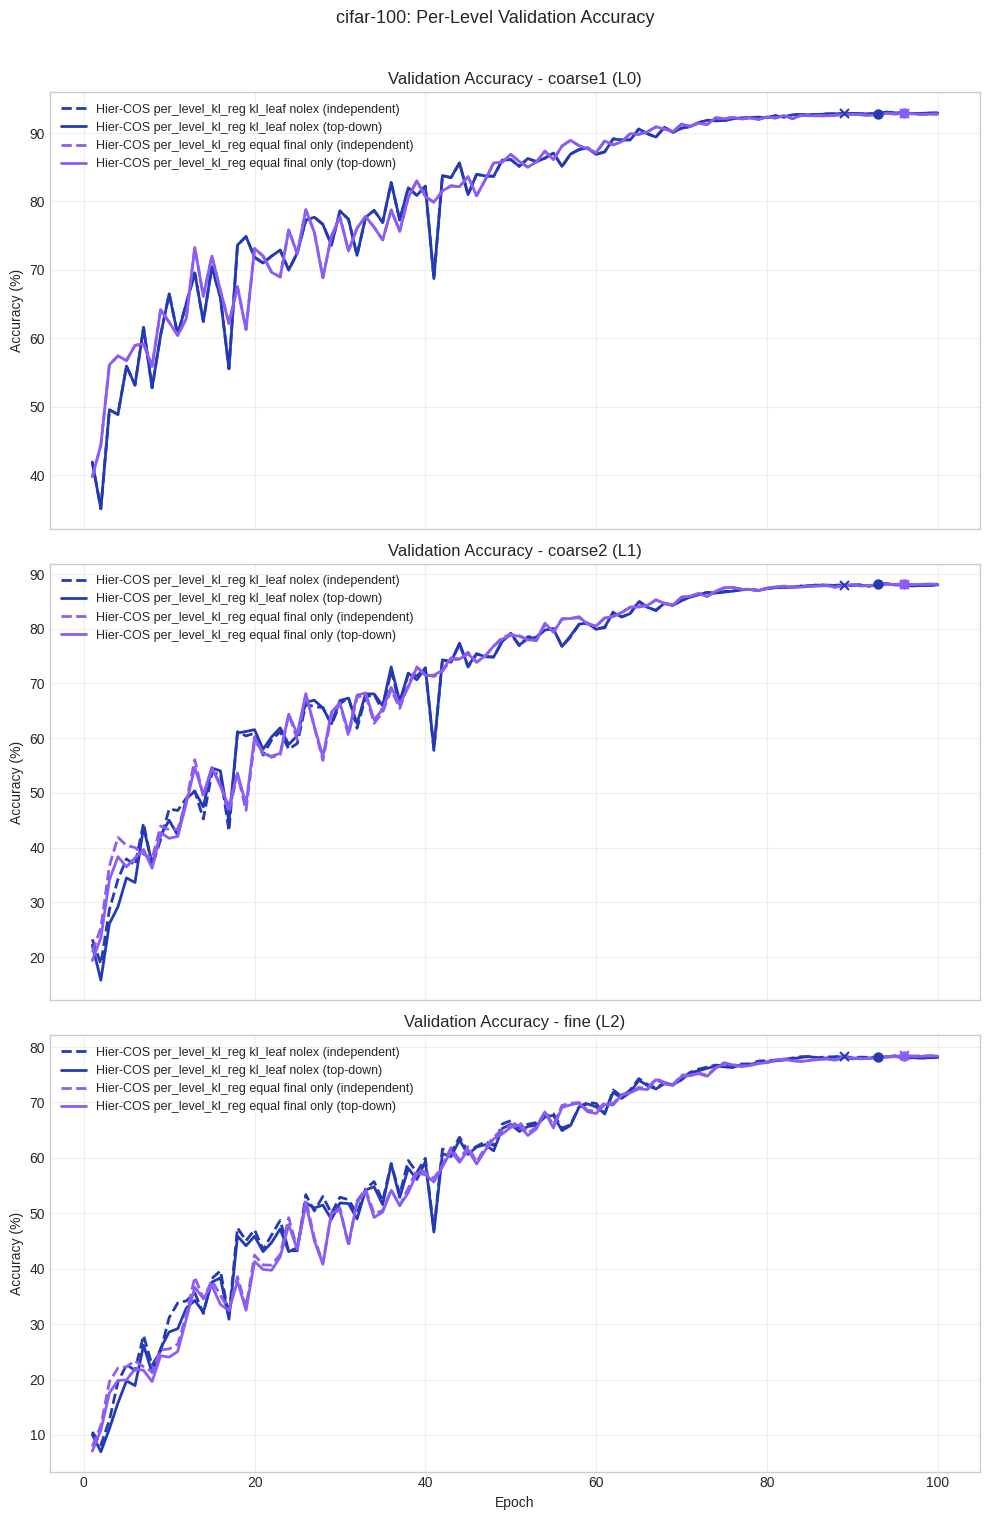

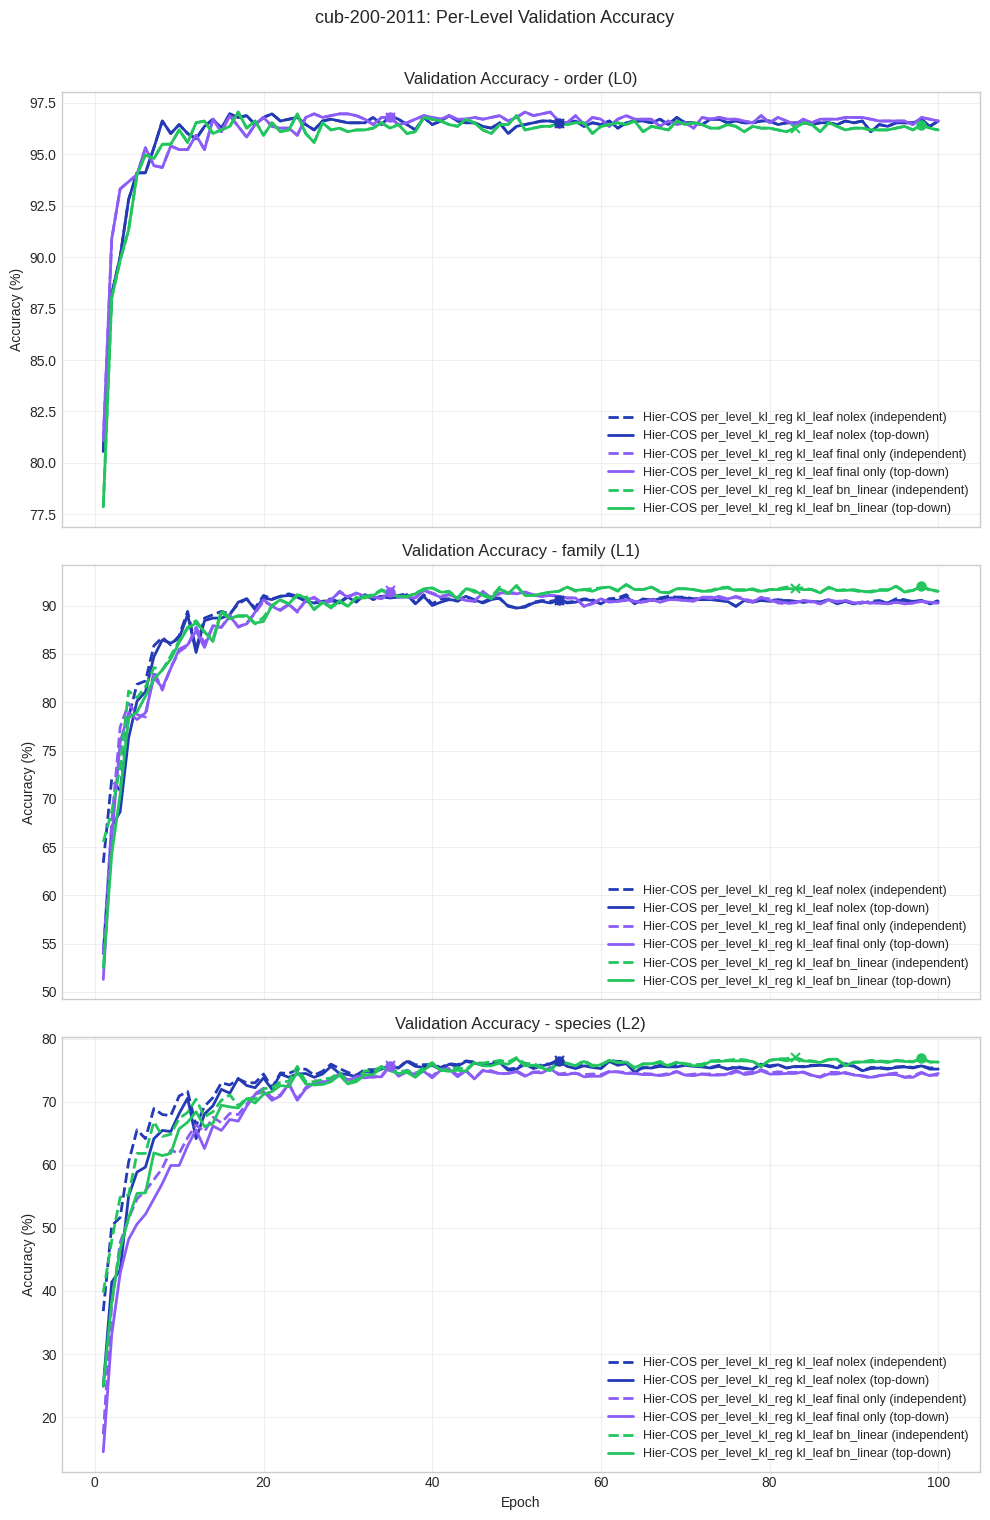

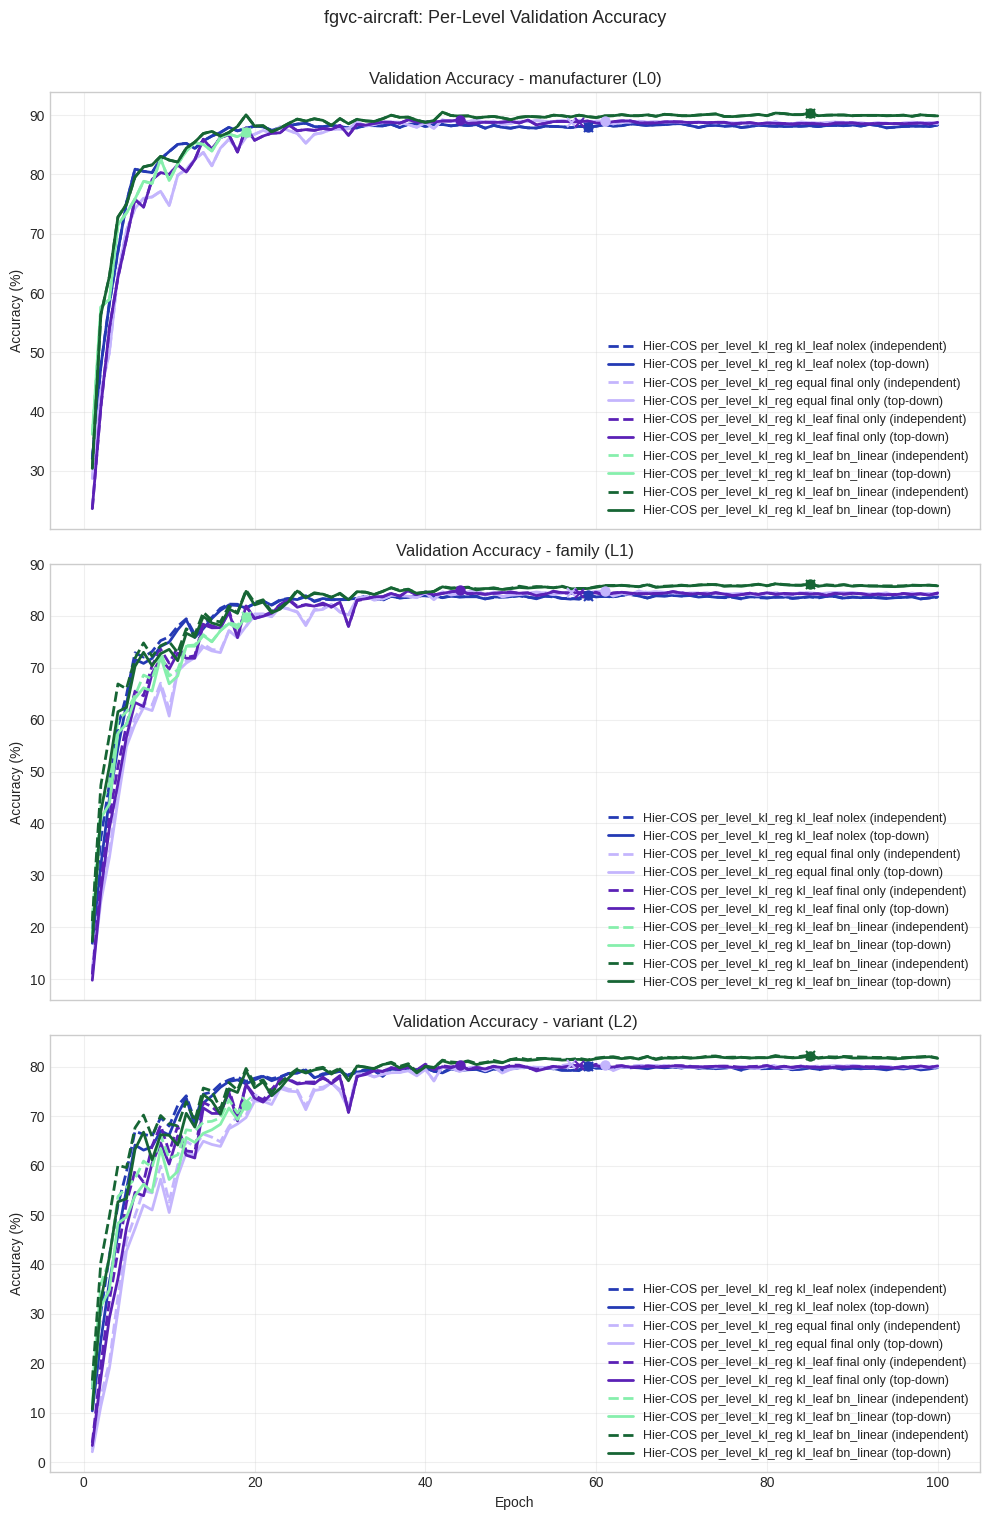

In [51]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset (typically the `kl_reg` baseline).


In [52]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **Hier-COS per_level_kl_reg kl_leaf nolex**

| Metric | Hier-COS per_level_kl_reg kl_leaf nolex | Hier-COS per_level_kl_reg equal final only |
|---|---:|---:|
| Best epoch (TD/Ind) | 93/89 | 96/96 |
| FPA independent ↑ | **77.60%** | <u>77.43% (-0.17 pp)</u> |
| FPA top-down ↑ | **78.04%** | <u>77.49% (-0.55 pp)</u> |
| wAP independent ↑ | **80.07%** | <u>79.93% (-0.14 pp)</u> |
| wAP top-down ↑ | **80.30%** | <u>79.90% (-0.40 pp)</u> |
| TICE independent ↓ | <u>1.09%</u> | **0.43% (-0.66 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.445</u> | **0.437 (-0.008)** |
| AHD top-down ↓ | **0.433** | <u>0.436 (+0.003)</u> |
| Acc independent coarse1 (L0) ↑ | <u>91.28%</u> | **91.67% (+0.39 pp)** |
| Acc top-down coarse1 (L0) ↑ | <u>91.55%</u> | **91.67% (+0.12 pp)** |
| Acc independent coarse2 (L1) ↑ | <u>86.79%</u> | **87.27% (+0.48 pp)** |
| Acc top-down coarse2 (L1) ↑ | <u>87.07%</u> | **87.24% (+0.17 pp)** |
| Acc independent fine (L2) ↑ | **77.83%** | <u>77.52% (-0.31 pp)</u> |
| Acc top-down fine (L2) ↑ | **78.04%** | <u>77.49% (-0.55 pp)</u> |

### Dataset: `cub-200-2011`
Baseline run: **Hier-COS per_level_kl_reg kl_leaf nolex**

| Metric | Hier-COS per_level_kl_reg kl_leaf nolex | Hier-COS per_level_kl_reg kl_leaf final only | Hier-COS per_level_kl_reg kl_leaf bn_linear |
|---|---:|---:|---:|
| Best epoch (TD/Ind) | 55/55 | 35/35 | 98/83 |
| FPA independent ↑ | **76.08%** | 74.11% (-1.96 pp) | <u>75.45% (-0.62 pp)</u> |
| FPA top-down ↑ | **76.22%** | 74.25% (-1.96 pp) | <u>75.33% (-0.89 pp)</u> |
| wAP independent ↑ | **79.52%** | 78.10% (-1.43 pp) | <u>79.16% (-0.36 pp)</u> |
| wAP top-down ↑ | **79.46%** | 77.88% (-1.58 pp) | <u>78.72% (-0.75 pp)</u> |
| TICE independent ↓ | **0.69%** | <u>0.89% (+0.19 pp)</u> | <u>0.89% (+0.19 pp)</u> |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.366** | 0.385 (+0.018) | <u>0.372 (+0.005)</u> |
| AHD top-down ↓ | **0.364** | 0.383 (+0.019) | <u>0.374 (+0.011)</u> |
| Acc independent order (L0) ↑ | 96.81% | **97.05% (+0.24 pp)** | <u>96.89% (+0.09 pp)</u> |
| Acc top-down order (L0) ↑ | 96.81% | **97.05% (+0.24 pp)** | <u>96.89% (+0.09 pp)</u> |
| Acc independent family (L1) ↑ | <u>90.56%</u> | 90.47% (-0.09 pp) | **90.59% (+0.03 pp)** |
| Acc top-down family (L1) ↑ | **90.62%** | <u>90.42% (-0.21 pp)</u> | 90.33% (-0.30 pp) |
| Acc independent species (L2) ↑ | **76.30%** | 74.51% (-1.79 pp) | <u>75.83% (-0.47 pp)</u> |
| Acc top-down species (L2) ↑ | **76.22%** | 74.25% (-1.96 pp) | <u>75.33% (-0.89 pp)</u> |

### Dataset: `fgvc-aircraft`
Baseline run: **Hier-COS per_level_kl_reg kl_leaf nolex**

| Metric | Hier-COS per_level_kl_reg kl_leaf nolex | Hier-COS per_level_kl_reg equal final only | Hier-COS per_level_kl_reg kl_leaf final only | Hier-COS per_level_kl_reg kl_leaf bn_linear | Hier-COS per_level_kl_reg kl_leaf bn_linear |
|---|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 59/59 | 61/57 | 44/58 | 19/19 | 85/85 |
| FPA independent ↑ | 80.20% | 80.50% (+0.30 pp) | <u>80.53% (+0.33 pp)</u> | n/a | **82.06% (+1.86 pp)** |
| FPA top-down ↑ | 80.41% | <u>80.86% (+0.45 pp)</u> | 80.17% (-0.24 pp) | n/a | **82.12% (+1.71 pp)** |
| wAP independent ↑ | 83.08% | <u>83.47% (+0.39 pp)</u> | 83.34% (+0.26 pp) | n/a | **84.58% (+1.50 pp)** |
| wAP top-down ↑ | 83.14% | <u>83.56% (+0.42 pp)</u> | 83.24% (+0.10 pp) | n/a | **84.47% (+1.33 pp)** |
| TICE independent ↓ | 1.35% | <u>0.75% (-0.60 pp)</u> | **0.57% (-0.78 pp)** | n/a | 0.87% (-0.48 pp) |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | n/a | **0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.467 | <u>0.456 (-0.011)</u> | 0.459 (-0.008) | n/a | **0.429 (-0.038)** |
| AHD top-down ↓ | 0.462 | <u>0.450 (-0.011)</u> | 0.456 (-0.005) | n/a | **0.428 (-0.033)** |
| Acc independent manufacturer (L0) ↑ | 88.82% | <u>88.97% (+0.15 pp)</u> | 88.73% (-0.09 pp) | n/a | **89.30% (+0.48 pp)** |
| Acc top-down manufacturer (L0) ↑ | 88.82% | <u>89.06% (+0.24 pp)</u> | 89.03% (+0.21 pp) | n/a | **89.30% (+0.48 pp)** |
| Acc independent family (L1) ↑ | 84.44% | <u>84.92% (+0.48 pp)</u> | <u>84.92% (+0.48 pp)</u> | n/a | **85.76% (+1.32 pp)** |
| Acc top-down family (L1) ↑ | 84.62% | 85.07% (+0.45 pp) | <u>85.16% (+0.54 pp)</u> | n/a | **85.76% (+1.14 pp)** |
| Acc independent variant (L2) ↑ | 80.41% | <u>80.80% (+0.39 pp)</u> | 80.62% (+0.21 pp) | n/a | **82.33% (+1.92 pp)** |
| Acc top-down variant (L2) ↑ | 80.41% | <u>80.86% (+0.45 pp)</u> | 80.17% (-0.24 pp) | n/a | **82.12% (+1.71 pp)** |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
